In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('car_prices.csv')

- ID: unique car ID
- Year: year the car was made
- Make: car brand (e.g. Toyota)
- Model :car model (e.g. Corolla)
- Trim: version of the model
- Body: car type (sedan, SUV, etc.)
- Transmission: gearbox (auto/manual)
- VIN: Vehicle Identification Number ,a unique code for each car
- State: location of sale
- ConditionValue: condition rating
- Odometer: distance driven
- Color: outside color
- Interior: inside color
- Seller: who sells the car
- MMR: market price estimate
- SellingPrice: actual sale price
- SaleDate: date of sale

In [3]:
df

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
0,2,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,2014-12-16 04:30:00
1,3,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,2014-12-16 04:30:00
2,4,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,2015-01-14 20:30:00
3,5,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,2015-01-28 20:30:00
4,6,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18 04:30:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,558834,2015,Kia,K900,Luxury,Sedan,NaN,knalw4d4xf6019304,in,45.0,18255.0,silver,black,avis corporation,35300.0,33000.0,2015-07-09 00:00:00
558833,558835,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,white,black,i -5 uhlmann rv,30200.0,30800.0,2015-07-08 02:30:00
558834,558836,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,black,black,financial services remarketing (lease),29800.0,34000.0,2015-07-08 02:30:00
558835,558837,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,white,black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,2015-07-08 23:45:00


## Data representation

In [4]:
df.head()

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
0,2,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,2014-12-16 04:30:00
1,3,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,2014-12-16 04:30:00
2,4,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,2015-01-14 20:30:00
3,5,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,2015-01-28 20:30:00
4,6,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18 04:30:00


## DataExploration

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Id              558837 non-null  int64  
 1   Year            558837 non-null  int64  
 2   Make            548536 non-null  str    
 3   Model           548438 non-null  str    
 4   Trim            548186 non-null  str    
 5   Body            545642 non-null  str    
 6   Transmission    493485 non-null  str    
 7   VIN             558833 non-null  str    
 8   State           558837 non-null  str    
 9   ConditionValue  547017 non-null  float64
 10  Odometer        558743 non-null  float64
 11  Color           558088 non-null  str    
 12  Interior        558088 non-null  str    
 13  Seller          558837 non-null  str    
 14  MMR             558799 non-null  float64
 15  SellingPrice    558825 non-null  float64
 16  SaleDate        558799 non-null  str    
dtypes: float64(4), int64(

In [6]:
df.isna().sum()
    

Id                    0
Year                  0
Make              10301
Model             10399
Trim              10651
Body              13195
Transmission      65352
VIN                   4
State                 0
ConditionValue    11820
Odometer             94
Color               749
Interior            749
Seller                0
MMR                  38
SellingPrice         12
SaleDate             38
dtype: int64

In [7]:
df.isna().sum().sum()

np.int64(123402)

In [8]:
df.duplicated().sum()

np.int64(0)

### Missing Values
Upon inspecting the dataset for completeness, the following observations were made:

* **Variable Distribution:** Missing data is present across several key features, including *Make, Model, Trim, Body, VIN, Condition Value, Odometer, Color, Interior, MMR, Selling Price,* and *Sale Date*.
* **Primary Issue:** The **Transmission** column is identified as the most problematic variable, containing the **highest number of missing entries** compared to any other column in the dataset.
* **Impact:** The total count of missing values across all columns reaches **123,320**. This high concentration of missing data in the Transmission category required specific attention during the cleaning phase to ensure the integrity of the subsequent analysis.

### Duplicates
The dataset was checked for duplicate records, and no duplicates were found.


## uni variate

In [9]:
df.head()

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
0,2,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,2014-12-16 04:30:00
1,3,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,2014-12-16 04:30:00
2,4,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,2015-01-14 20:30:00
3,5,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,2015-01-28 20:30:00
4,6,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18 04:30:00


In [10]:
df['Year'].value_counts().sort_index()## from 1982>>>2015

Year
1982         2
1983         1
1984         5
1985        10
1986        11
1987         8
1988        11
1989        20
1990        49
1991        67
1992       132
1993       205
1994       392
1995       711
1996       851
1997      1546
1998      2149
1999      3363
2000      5227
2001      6468
2002      9715
2003     13281
2004     17342
2005     21394
2006     26913
2007     30845
2008     31502
2009     20594
2010     26485
2011     48548
2012    102315
2013     98168
2014     81070
2015      9437
Name: count, dtype: int64

In [11]:
df['Year'].value_counts()

Year
2012    102315
2013     98168
2014     81070
2011     48548
2008     31502
2007     30845
2006     26913
2010     26485
2005     21394
2009     20594
2004     17342
2003     13281
2002      9715
2015      9437
2001      6468
2000      5227
1999      3363
1998      2149
1997      1546
1996       851
1995       711
1994       392
1993       205
1992       132
1991        67
1990        49
1989        20
1986        11
1988        11
1985        10
1987         8
1984         5
1982         2
1983         1
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

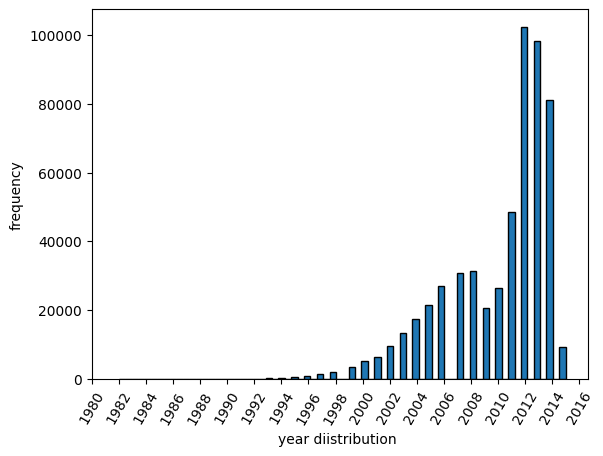

In [12]:
plt.Figure(figsize=[12,6])
plt.hist(df['Year'],bins=70,edgecolor="black")
plt.xticks([i for i in range(1980,2017,2)])
plt.xticks(rotation=60)
plt.xlabel('year diistribution ')
plt.ylabel('frequency')
plt.show
## 2011>>>>2014  bestsellers



* **Recent Cars are Popular:** Most cars sold were made between **2011 and 2014**. This shows that people prefer buying relatively newer cars.
* **Older Cars vs. Newer Cars:** Interestingly, cars from **2007 and 2008** sold more than some newer models from **2009 and 2010**.
* **Main Finding:** This means the year of the car isn't everything. Other things, like **brand reputation** and how much people like a **specific model**, are very important for sales.

In [13]:
df['Make'].head()

0      Kia
1      Kia
2      BMW
3    Volvo
4      BMW
Name: Make, dtype: str

In [14]:
df['Make'].unique()

<StringArray>
[          'Kia',           'BMW',         'Volvo',        'Nissan',
     'Chevrolet',          'Audi',          'Ford',       'Hyundai',
         'Buick',      'Cadillac',         'Acura',         'Lexus',
      'Infiniti',          'Jeep', 'Mercedes-Benz',    'Mitsubishi',
         'Mazda',          'MINI',    'Land Rover',       'Lincoln',
       'lincoln',        'Jaguar',    'Volkswagen',        'Toyota',
        'Subaru',         'Scion',       'Porsche',             nan,
           'bmw',         'Dodge',          'FIAT',      'Chrysler',
          'ford',       'Ferrari',         'Honda',           'GMC',
    'mitsubishi',           'Ram',         'smart',     'chevrolet',
       'Bentley',      'chrysler',       'pontiac',       'Pontiac',
        'Saturn',      'Maserati',       'Mercury',        'HUMMER',
     'landrover',      'cadillac',    'land rover',      'mercedes',
         'mazda',        'toyota',         'lexus',     'gmc truck',
         'honda',   

In [15]:
df['Make'].isna().sum()

np.int64(10301)

In [16]:
top_5=df['Make'].value_counts().head(5)
top_5

Make
Ford         93554
Chevrolet    60197
Nissan       53946
Toyota       39871
Dodge        30710
Name: count, dtype: int64

In [17]:
top_5=df['Make'].value_counts(normalize=True)*100
top_5

Make
Ford          17.055216
Chevrolet     10.974120
Nissan         9.834541
Toyota         7.268620
Dodge          5.598539
                ...    
chev truck     0.000182
ford tk        0.000182
airstream      0.000182
dot            0.000182
Lotus          0.000182
Name: proportion, Length: 96, dtype: float64

In [18]:
lowest_make=df['Make'].value_counts().tail(5)
lowest_make

Make
chev truck    1
ford tk       1
airstream     1
dot           1
Lotus         1
Name: count, dtype: int64

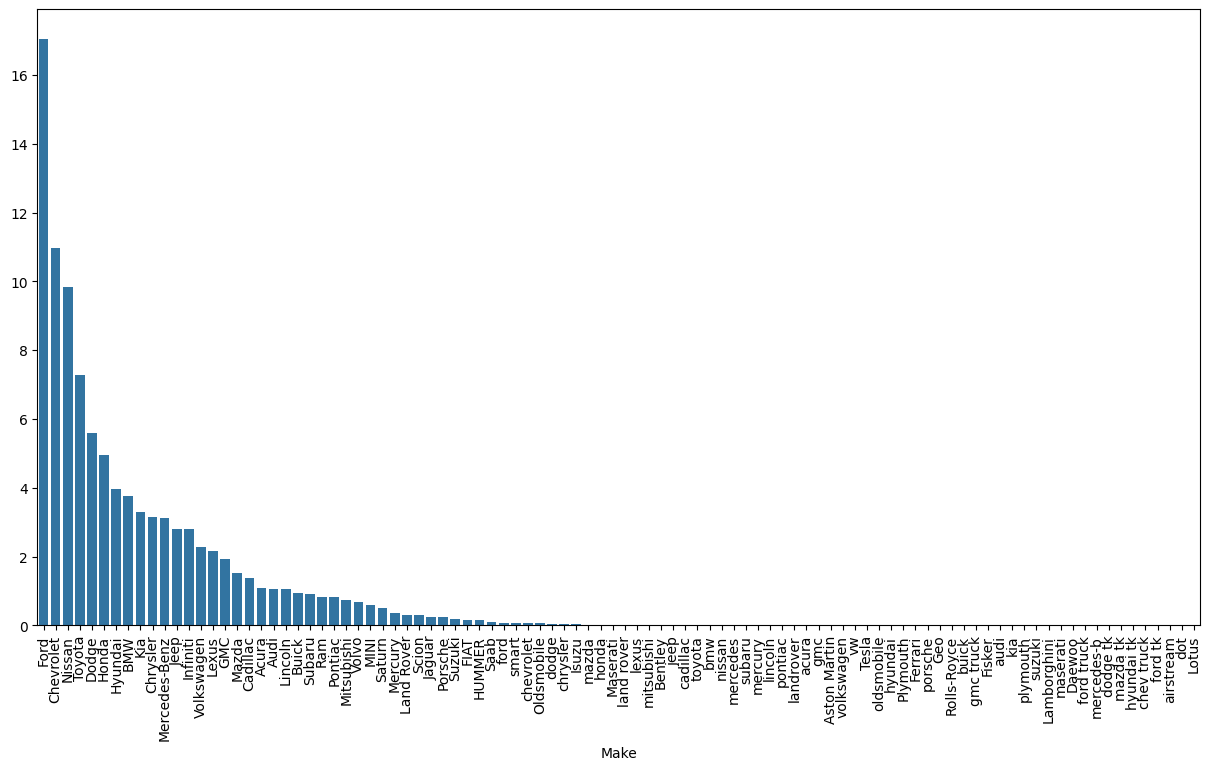

In [19]:
plt.figure(figsize=[15,8])
sns.barplot(x=top_5.index,y=top_5.values)
plt.xticks(rotation=90)
plt.show()
## ford is the bestseller


* **Mainstream Popularity:** The market is led by five major brands: **Ford (17.06%)**, **Chevrolet (10.97%)**, **Nissan (9.83%)**, **Toyota (7.27%)**, and **Dodge (5.60%)**.
* **Niche Brands:** In contrast, brands like **Lotus, Airstream, Dot, Chev Truck, and Ford TK** have the lowest sales numbers.
* **Key Insight:** This shows that **mainstream brands dominate** the market, while niche or luxury brands represent only a very small part of total sales.

In [20]:
df['Model'].unique()

<StringArray>
[            'Sorento',            '3 Series',                 'S60',
 '6 Series Gran Coupe',              'Altima',                  'M5',
               'Cruze',                  'A4',              'Camaro',
                  'A6',
 ...
               'Metro',  'Grand Cherokee SRT',                'RC F',
                  'Q3', '4 Series Gran Coupe',              'RC 350',
                 '360',           'GLA-Class',                 'TLX',
          '458 Italia']
Length: 974, dtype: str

In [21]:
df['Model'].isna().sum()

np.int64(10399)

In [22]:
top_model=df['Model'].value_counts().head(5)
top_model

Model
Altima    19349
F-150     14479
Fusion    12946
Camry     12545
Escape    11861
Name: count, dtype: int64

In [23]:
df['Model'].value_counts().tail(5)

Model
Grand Cherokee SRT    1
Q3                    1
360                   1
TLX                   1
458 Italia            1
Name: count, dtype: int64

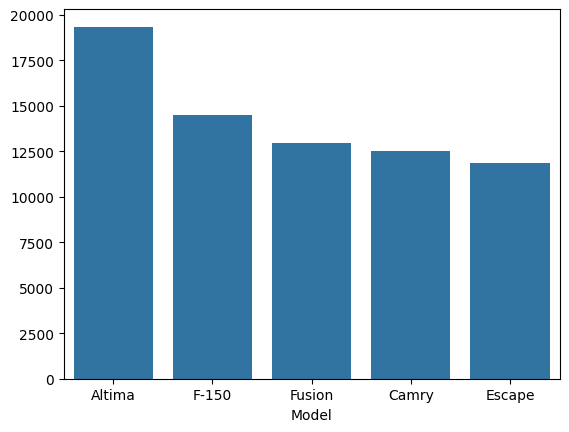

In [24]:
plt.Figure(figsize=[12,6])
sns.barplot(x=top_model.index,y=top_model.values)
plt.show()

* **Popular Models:** The most sold models in the dataset are the **Altima, F-150, Fusion, Camry, and Escape**.
* **Luxury & Rare Models:** On the other hand, high-end or luxury models like the **Grand Cherokee SRT, Q3, 360, TLX, and 458 Italia** have the lowest sales.
* **Key Insight:** This shows that buyers clearly prefer **reliable, mainstream models** for their daily needs, while expensive luxury cars are sold much less often.

In [25]:
df.head()

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
0,2,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,2014-12-16 04:30:00
1,3,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,2014-12-16 04:30:00
2,4,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,2015-01-14 20:30:00
3,5,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,2015-01-28 20:30:00
4,6,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18 04:30:00


In [26]:
df['Trim'].value_counts()

Trim
Base                  55817
SE                    43648
LX                    20757
Limited               18367
LT                    16915
                      ...  
S E-Hybrid                1
4.2 quattro Spyder        1
pure                      1
EWB                       1
Power Wagon               1
Name: count, Length: 1963, dtype: int64

In [27]:
df['Trim'].isna().sum()

np.int64(10651)

In [28]:
Top_trim=df['Trim'].value_counts().head(5)
Top_trim

Trim
Base       55817
SE         43648
LX         20757
Limited    18367
LT         16915
Name: count, dtype: int64


* **Most Popular Trims:** The top 5 trims sold are **Base, SE, LX, Limited, and LT**. 
* **Rare & Specialized Trims:** Trims like the **S E-Hybrid, 4.2 Quattro Spyder, Pure, EWB, and Power Wagon** have the lowest sales.
* **Key Insight:** This suggests that **standard trims dominate** the market, while highly specialized or expensive trims attract very few buyers.

In [29]:
df['Body'].unique()

<StringArray>
[                    'SUV',                   'Sedan',
             'Convertible',                   'Coupe',
                   'Wagon',               'Hatchback',
                'Crew Cab',                 'G Coupe',
                 'G Sedan',           'Elantra Coupe',
           'Genesis Coupe',                 'Minivan',
                       nan,                     'Van',
              'Double Cab',             'CrewMax Cab',
              'Access Cab',                'King Cab',
               'SuperCrew',               'CTS Coupe',
            'Extended Cab',            'E-Series Van',
                'SuperCab',             'Regular Cab',
           'G Convertible',                    'Koup',
                'Quad Cab',             'CTS-V Coupe',
                   'sedan',         'G37 Convertible',
                'Club Cab',                 'Xtracab',
         'Q60 Convertible',               'CTS Wagon',
             'convertible',               'G37 Coup

In [30]:
df['Body'] = df['Body'].str.lower().str.strip()

mapping = {
    # SUV
    'suv': 'SUV',

    # Sedan
    'sedan': 'Sedan',
    'g sedan': 'Sedan',

    # Convertible
    'convertible': 'Convertible',
    'g convertible': 'Convertible',
    'g37 convertible': 'Convertible',
    'beetle convertible': 'Convertible',
    'gran turismo convertible': 'Convertible',
    'granturismo convertible': 'Convertible',
    'q60 convertible': 'Convertible',

    # Coupe
    'coupe': 'Coupe',
    'g coupe': 'Coupe',
    'g37 coupe': 'Coupe',
    'elantra coupe': 'Coupe',
    'genesis coupe': 'Coupe',
    'cts coupe': 'Coupe',
    'koup': 'Coupe',
    'cts-v coupe': 'Coupe',
    'q60 coupe': 'Coupe',

    # Wagon / Hatchback
    'wagon': 'Wagon',
    'cts wagon': 'Wagon',
    'tsx sport wagon': 'Wagon',
    'cts-v wagon': 'CTS-V Wagon',
    'hatchback': 'Hatchback',

    # Minivan / Van
    'van': 'Van',
    'minivan': 'Van',
    'e-series van': 'Van',
    'promaster cargo van': 'Van',
    'transit van': 'Van',
    'ram van': 'Van',

    # Crew / Cab types
    'crew cab': 'Crew Cab',
    'double cab': 'Crew Cab',
    'quad cab': 'Crew Cab',
    'club cab': 'Crew Cab',
    'mega cab': 'Crew Cab',
    'cab plus': 'Crew Cab',
    'cab plus 4': 'Crew Cab',
    'supercrew': 'Crew Cab',
    'supercab': 'Crew Cab',
    'access cab': 'Crew Cab',
    'extended cab': 'Crew Cab',
    'crewmax cab': 'Crew Cab',
    'king cab': 'Crew Cab',
    'xtracab': 'Crew Cab',
    'regular-cab': 'Crew Cab',
    'regular cab': 'Crew Cab',

    # Minor duplicates capitalization / spacing
    'g coupe': 'Coupe',
    'g37 coupe': 'Coupe',
    'g37 convertible': 'Convertible',
    'tsx sport wagon': 'Wagon',
    'promaster cargo van': 'Van',
    'gran turismo convertible': 'Convertible'
}

df['Body'] = df['Body'].replace(mapping)


In [31]:
df['Body'].unique()

<StringArray>
[        'SUV',       'Sedan', 'Convertible',       'Coupe',       'Wagon',
   'Hatchback',    'Crew Cab',         'Van',           nan, 'CTS-V Wagon',
 'navitgation']
Length: 11, dtype: str

In [32]:
df['Body'].value_counts()

Body
Sedan          248760
SUV            143844
Crew Cab        47540
Van             31959
Hatchback       26237
Coupe           20163
Wagon           16179
Convertible     10933
navitgation        26
CTS-V Wagon         1
Name: count, dtype: int64

In [33]:
df['Body'].isna().sum()

np.int64(13195)

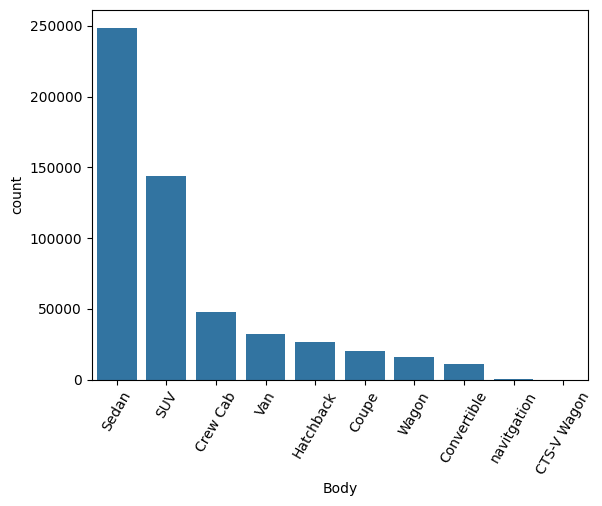

In [34]:
plt.Figure(figsize=[12,6])
sns.barplot(x=df['Body'].value_counts().index,y=df['Body'].value_counts())
plt.xticks(rotation=60)
plt.show()


* **Popular Trims:** The top 5 trims sold are **Base, SE, LX, Limited, and LT**. 
* **Rare Trims:** Specialized trims like the **S E-Hybrid, 4.2 Quattro Spyder, Pure, EWB, and Power Wagon** have the lowest sales.
* **Trim Insight:** This shows that **standard trims dominate** the market, while specialized versions attract very few buyers.

* **Body Column Cleaning:** The **Body** column was organized using mapping to fix inconsistent names.
* **Standardization:** For example, different spellings for **"Sedan"** and **"SUV"** were combined into single categories.
* **Better Accuracy:** This ensures the analysis is correct and prevents mistakes in how car types are counted.

In [35]:
df.head()

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
0,2,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,2014-12-16 04:30:00
1,3,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,2014-12-16 04:30:00
2,4,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,2015-01-14 20:30:00
3,5,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,2015-01-28 20:30:00
4,6,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18 04:30:00


In [36]:
df['Transmission'].value_counts()

Transmission
automatic    475915
manual        17544
sedan            15
Sedan            11
Name: count, dtype: int64

In [37]:
wrong_data=df[df["Transmission"].isin(["Sedan", "sedan"])]
wrong_data

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
408161,408163,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,navitgation,Sedan,automatic,3vwd17aj4fm201708,NaN,46.0,4802,silver,gray,NaN,13200.0,NaN
417835,417837,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,navitgation,Sedan,automatic,3vwd17aj2fm258506,NaN,1.0,9410,white,gray,NaN,13300.0,NaN
421289,421291,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,navitgation,Sedan,automatic,3vwd17aj3fm276741,NaN,46.0,1167,blue,black,NaN,13200.0,NaN
424161,424163,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,navitgation,Sedan,automatic,3vwd17aj2fm285365,NaN,1.0,2172,gray,black,NaN,14050.0,NaN
427040,427042,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,navitgation,Sedan,automatic,3vwd17aj0fm227318,NaN,41.0,14872,gray,black,NaN,13700.0,NaN
427043,427045,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,navitgation,Sedan,automatic,3vwd17aj6fm218641,NaN,49.0,12655,red,black,NaN,13850.0,NaN
434424,434426,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,navitgation,Sedan,automatic,3vwd17aj7fm223475,NaN,46.0,15719,blue,black,NaN,13650.0,NaN
444501,444503,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,navitgation,Sedan,automatic,3vwd17aj5fm297123,NaN,2.0,6388,white,black,NaN,13850.0,NaN
453794,453796,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,navitgation,Sedan,automatic,3vwd17aj5fm219943,NaN,44.0,16633,silver,black,NaN,13600.0,NaN
461597,461599,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,navitgation,Sedan,automatic,3vwd17aj9fm219766,NaN,44.0,11034,black,black,NaN,13900.0,NaN


In [38]:
df.drop(index=wrong_data.index, inplace=True)


In [39]:
df.reset_index(drop=True,inplace=True)

In [40]:
df['Transmission'].value_counts()

Transmission
automatic    475915
manual        17544
Name: count, dtype: int64

In [41]:
df['Transmission'].value_counts(normalize=True)*100

Transmission
automatic    96.444689
manual        3.555311
Name: proportion, dtype: float64

In [42]:
df['Transmission'].isna().sum()

np.int64(65352)


* **Fixing Errors:** The **Transmission** column had some incorrect and inconsistent values.
* **Cleaning Process:** These wrong values were removed to keep the analysis accurate and avoid any bias.
* **Key Finding:** After cleaning the data, it was confirmed that over **96%** of the vehicles have an **Automatic transmission**.
* **Market Trend:** This reflects the true nature of the dataset, showing that automatic cars are the standard choice for most buyers.

In [43]:
df['State'].unique()

<StringArray>
['ca', 'tx', 'pa', 'mn', 'az', 'wi', 'tn', 'md', 'fl', 'ne', 'nj', 'nv', 'oh',
 'mi', 'ga', 'va', 'sc', 'nc', 'in', 'il', 'co', 'ut', 'mo', 'ny', 'ma', 'pr',
 'or', 'la', 'wa', 'hi', 'qc', 'ab', 'on', 'ok', 'ms', 'nm', 'al', 'ns']
Length: 38, dtype: str

In [44]:
df['State'].value_counts()

State
fl    82945
ca    73148
pa    53907
tx    45913
ga    34750
nj    27784
il    23486
nc    21845
oh    21575
tn    20895
mo    16013
mi    15511
nv    12685
va    12027
md    11158
wi     9851
mn     9429
az     8741
co     7775
wa     7416
ma     6729
ny     5699
in     4325
sc     4251
ne     4013
on     3442
pr     2725
la     2191
ms     1851
ut     1836
qc     1245
hi     1237
or     1155
ab      928
nm      171
ok       72
ns       61
al       26
Name: count, dtype: int64

In [45]:
top_10_states=df['State'].value_counts().head(10)
top_10_states

State
fl    82945
ca    73148
pa    53907
tx    45913
ga    34750
nj    27784
il    23486
nc    21845
oh    21575
tn    20895
Name: count, dtype: int64

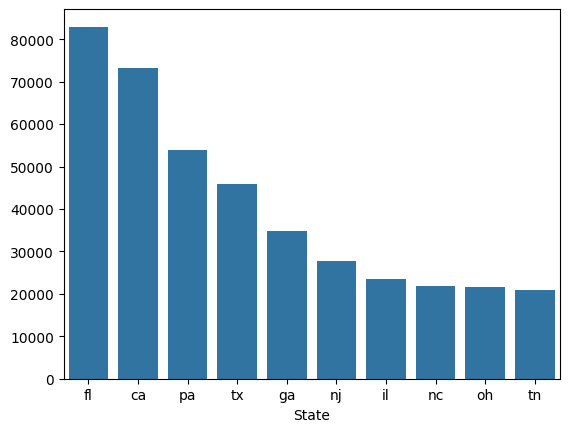

In [46]:
plt.Figure(figsize=[12,6])
sns.barplot(x=top_10_states.index,y=top_10_states.values)
plt.show()

In [47]:
df['State'].isna().sum()

np.int64(0)

* **Most Active States:** The majority of cars were sold in **FL, CA, PA, TX, and GA**.

In [48]:
df['ConditionValue'].unique()

array([ 5., 45., 41., 43.,  1., 34.,  2., 42.,  3., 48., nan, 49., 17.,
       19., 29., 38., 44., 47., 32.,  4., 25., 37., 39., 31., 28., 46.,
       36., 35., 26., 21., 22., 27., 24., 33., 23., 15., 16., 18., 12.,
       14., 11., 13.])

In [49]:
df['ConditionValue'].nunique()

41

In [50]:
df.loc[df['ConditionValue'] > 5, 'ConditionValue'] = df['ConditionValue'] / 10

In [51]:
df['ConditionValue']

0         5.0
1         5.0
2         4.5
3         4.1
4         4.3
         ... 
558806    4.5
558807    5.0
558808    4.8
558809    3.8
558810    3.4
Name: ConditionValue, Length: 558811, dtype: float64

In [52]:
df['ConditionValue'].max()

np.float64(5.0)

In [53]:
df['ConditionValue'].describe()

count    547017.000000
mean          3.424512
std           0.949439
min           1.000000
25%           2.700000
50%           3.600000
75%           4.200000
max           5.000000
Name: ConditionValue, dtype: float64

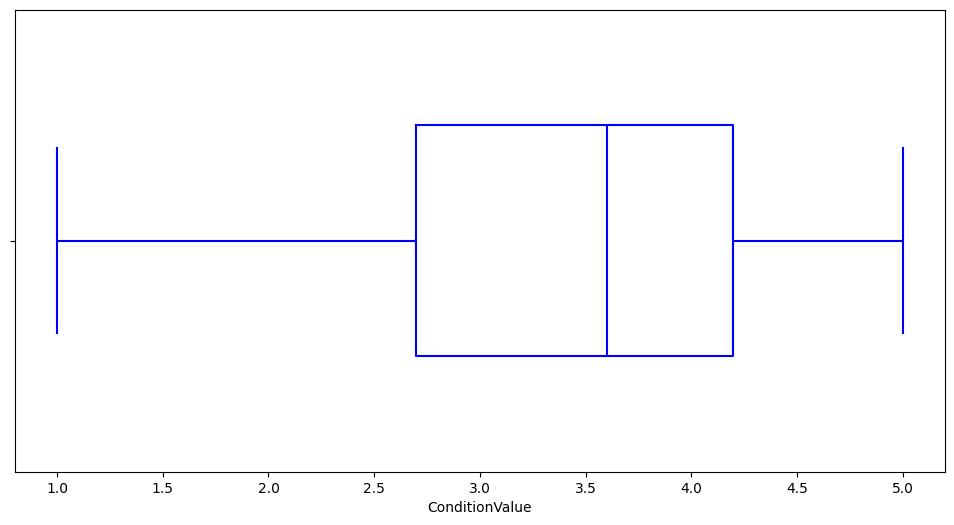

In [54]:
plt.figure(figsize=[12,6])
sns.boxplot(data=df,x='ConditionValue',widths=0.5,color="blue", saturation=0.6, fill=False)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

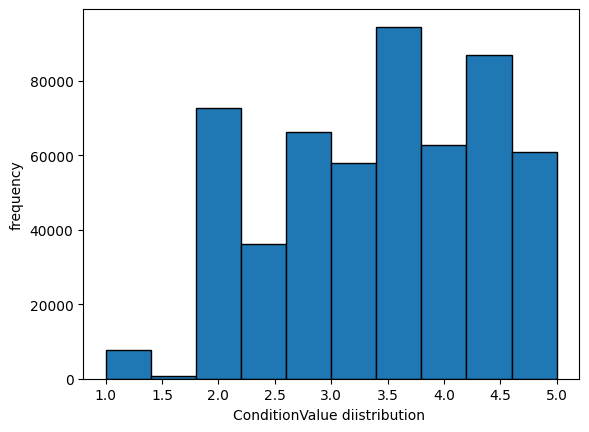

In [55]:
plt.Figure(figsize=[12,6])
plt.hist(df['ConditionValue'],edgecolor="black")
plt.xlabel('ConditionValue diistribution ')
plt.ylabel('frequency')
plt.show


* **Condition Range:** Vehicle conditions are rated on a scale of **1 to 5**, with an average score of **3.42**. This shows that most cars are in moderate to good condition.
* **Above Average:** The median value is **3.6**, which means more than half of the vehicles in the dataset are in better-than-average condition.
* **Typical Range:** Most cars fall between **2.7 and 4.2**, with many scores clustering around **3.5 to 4**.
* **Key Insight:** This data reflects a generally high standard for the vehicles being sold, as the majority are maintained in good overall condition.

In [56]:
df.head()

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
0,2,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,2014-12-16 04:30:00
1,3,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,2014-12-16 04:30:00
2,4,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,4.5,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,2015-01-14 20:30:00
3,5,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,4.1,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,2015-01-28 20:30:00
4,6,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,4.3,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18 04:30:00


In [57]:
df['Odometer'].describe()

count    558717.000000
mean      68323.195797
std       53397.752933
min           1.000000
25%       28374.000000
50%       52256.000000
75%       99112.000000
max      999999.000000
Name: Odometer, dtype: float64

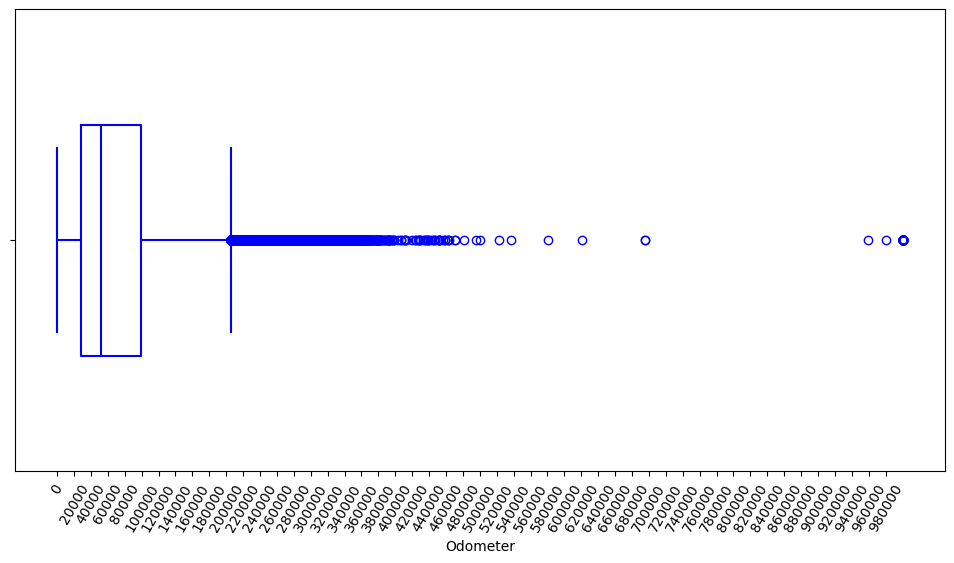

In [58]:
plt.figure(figsize=[12,6])
sns.boxplot(data=df,x='Odometer',widths=0.5,color="blue", saturation=0.6, fill=False)
plt.xticks(range(0, int(df['Odometer'].max()), 20000))
plt.xticks(rotation=60)
plt.show()


* **Mileage Range:** The mileage in the dataset varies greatly, ranging from very low numbers to nearly **1,000,000 km**.
* **Average vs. Median:** The average mileage is about **68,000 km**, but the median is much lower at **52,000 km**. 
* **Data Entry Note:** Some readings show **1,000,000 km**, which are likely **data entry errors**. These extreme values act as outliers and make the average look higher than it really is for most cars.
* **Typical Usage:** Most vehicles fall between **28,000 and 99,000 km**, showing that the majority of cars have moderate and realistic usage.
* **Key Insight:** There is a clear link between mileage and quality; as the **Odometer reading goes up, the Condition Value tends to go down** due to normal wear and tear.

In [59]:
df['Color'].unique()

<StringArray>
[    'white',      'gray',     'black',       'red',    'silver',      'blue',
     'brown',     'beige',    'purple',  'burgundy',         '—',      'gold',
    'yellow',     'green',  'charcoal',         nan,    'orange', 'off-white',
 'turquoise',      'pink',      'lime']
Length: 21, dtype: str

In [60]:
df['Color'].value_counts()

Color
black        110970
white        106673
silver        83389
gray          82857
blue          51139
red           43569
—             24685
green         11382
gold          11342
beige          9222
burgundy       8972
brown          6717
orange         2078
purple         1561
off-white      1449
yellow         1285
charcoal        479
turquoise       236
pink             42
lime             15
Name: count, dtype: int64

In [61]:
df['Color'].isna().sum()

np.int64(749)

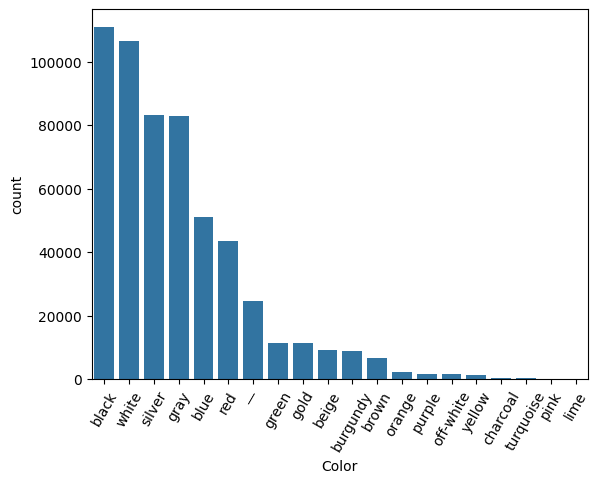

In [62]:
plt.Figure(figsize=[12,6])
sns.barplot(x=df['Color'].value_counts().index,y=df['Color'].value_counts())
plt.xticks(rotation=60)
plt.show()

In [63]:
df['Interior'].unique()

<StringArray>
[    'black',     'beige',       'tan',         '—',      'gray',     'brown',
  'burgundy',     'white',         nan,    'silver', 'off-white',      'blue',
       'red',    'yellow',     'green',    'purple',    'orange',      'gold']
Length: 18, dtype: str

In [64]:
df['Interior'].value_counts()

Interior
black        244325
gray         178578
beige         59758
tan           44093
—             17076
brown          8640
red            1359
blue           1138
silver         1099
off-white       480
purple          339
gold            324
white           252
green           245
burgundy        191
orange          145
yellow           20
Name: count, dtype: int64

In [65]:
df['Interior'].isna().sum()

np.int64(749)

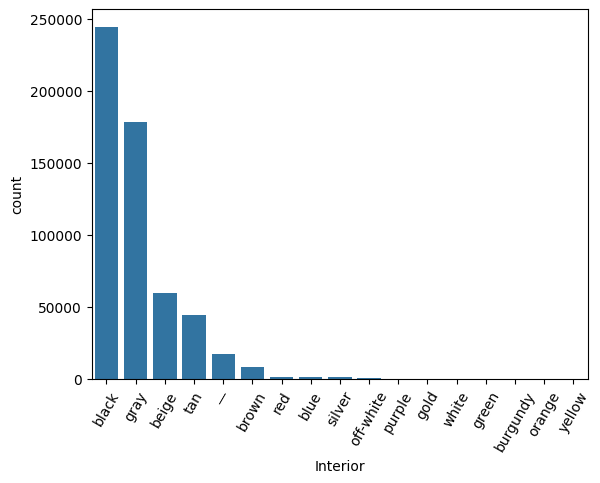

In [66]:
plt.Figure(figsize=[12,6])
sns.barplot(x=df['Interior'].value_counts().index,y=df['Interior'].value_counts())
plt.xticks(rotation=60)
plt.show()


* **Exterior Colors:** The most popular car colors are **Black and White**, which reflects the most common preferences for buyers in the market.
* **Interior Colors:** The most frequent interior colors are **Black and Gray**, staying consistent with the neutral trends seen on the exterior.
* **Key Insight:** Most vehicles in the dataset follow a classic and professional color palette, as these combinations are generally easier to resell and maintain.

In [67]:
df['Seller'].unique()

<StringArray>
[                           'kia motors america  inc',
             'financial services remarketing (lease)',
                            'volvo na rep/world omni',
 'enterprise vehicle exchange / tra / rental / tulsa',
                              'the hertz corporation',
                                 'audi mission viejo',
                                 'd/m auto sales inc',
                                  'desert auto trade',
                                 'kia motors finance',
                               'avis rac/san leandro',
 ...
                                      'drive america',
                            'eynon pontiac buick inc',
                                'auto revolution llc',
                            't&s california auto inc',
                                  'magnum motors llc',
                                 'a-1 auto group llc',
                        'g brothers auto brokers inc',
                         'maserati north ameri

In [68]:
top_seller=df['Seller'].value_counts().head(5)
top_seller

Seller
nissan-infiniti lt               19693
ford motor credit company llc    19162
the hertz corporation            18299
santander consumer               15285
avis corporation                 12540
Name: count, dtype: int64

In [69]:
df['Seller'].value_counts().tail(5)

Seller
magnum motors llc                  1
a-1 auto group llc                 1
g brothers auto brokers inc        1
alternative financial group inc    1
i -5 uhlmann rv                    1
Name: count, dtype: int64

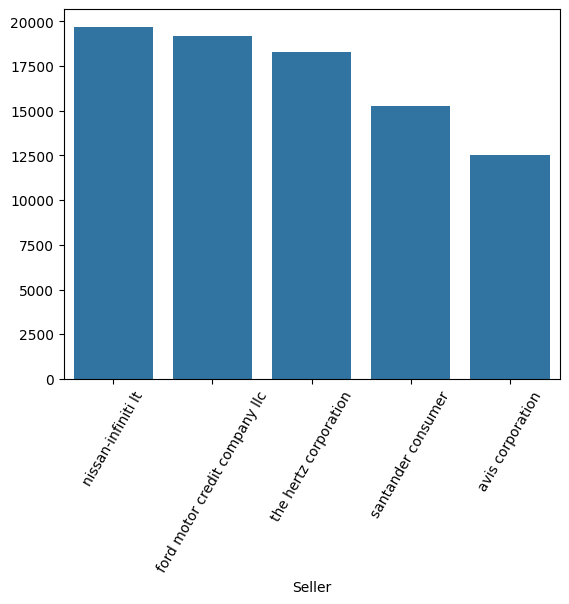

In [70]:
plt.Figure(figsize=[12,6])
sns.barplot(x=top_seller.index,y=top_seller.values)
plt.xticks(rotation=60)
plt.show()


* **Market Leaders:** The top 5 sellers by volume are **Nissan-Infiniti LT, Ford Motor Credit Company LLC, The Hertz Corporation, Santander Consumer, and Avis Corporation**.
* **Corporate Influence:** These major sellers dominate the market, which shows that a large part of the sales comes from **fleets and corporate companies** (like rental and finance firms).
* **Key Insight:** The high presence of rental companies and credit institutions suggests that many cars in the dataset are likely former rentals or off-lease vehicles.

In [71]:
df['MMR'].describe()

count    558799.000000
mean      13769.377495
std        9679.967174
min          25.000000
25%        7100.000000
50%       12250.000000
75%       18300.000000
max      182000.000000
Name: MMR, dtype: float64

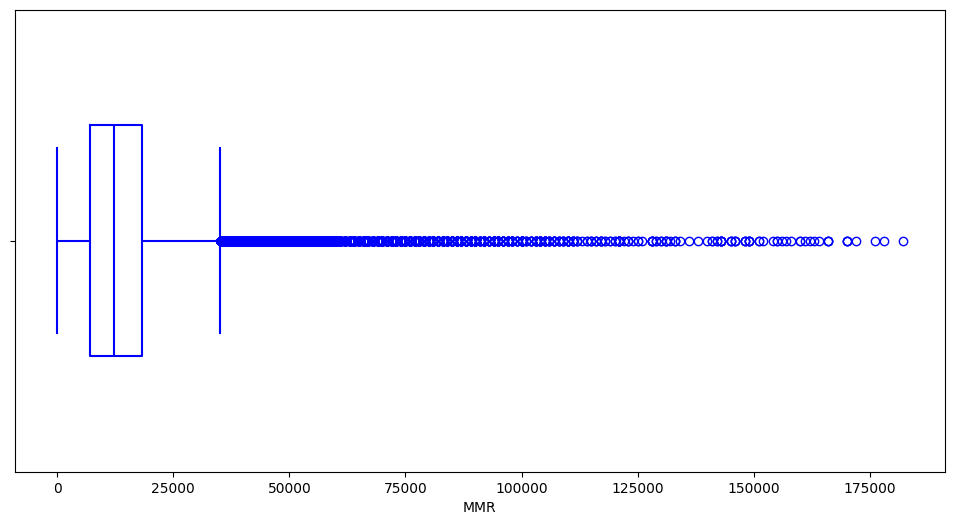

In [72]:
plt.figure(figsize=[12,6])
sns.boxplot(data=df,x='MMR',widths=0.5,color="blue", saturation=0.6, fill=False)
plt.show()

In [73]:
Q1 = df['MMR'].quantile(0.25)
Q3 = df['MMR'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count = df[(df['MMR'] < lower_bound) | (df['MMR'] > upper_bound)].shape[0]

print(f" num_outliers: {outliers_count}")

 num_outliers: 16315


In [74]:
df.loc[df['MMR'].idxmax()]

Id                             548171
Year                             2011
Make                          Ferrari
Model                      458 Italia
Trim                             Base
Body                            Coupe
Transmission                automatic
VIN                 zff67nfa1b0178698
State                              fl
ConditionValue                    4.6
Odometer                      12116.0
Color                             red
Interior                        black
Seller            platinum motor cars
MMR                          182000.0
SellingPrice                 183000.0
SaleDate          2015-06-16 20:40:00
Name: 548146, dtype: object

In [75]:
df.loc[df['MMR'].idxmin()]

Id                                     4954
Year                                   2001
Make                               Chrysler
Model                               Sebring
Trim                                     LX
Body                            Convertible
Transmission                      automatic
VIN                       1c3el45u71n673716
State                                    ca
ConditionValue                          1.0
Odometer                           223707.0
Color                                  blue
Interior                               gray
Seller            purple heart services inc
MMR                                    25.0
SellingPrice                          300.0
SaleDate                2014-12-30 08:00:00
Name: 4952, dtype: object



* **Price Range & Data Issues:** Market values (MMR) range from **25** to **182,000**. The minimum value of **25** is likely a **data entry error**, as it is far too low to represent the actual market retail price of any functional vehicle.
* **Average vs. Median:** The average price is about **13,769**, while the median is **12,250**. This shows that the majority of cars are priced on the lower end, and the distribution is pushed upward by high-value vehicles.
* **Luxury Outliers:** The maximum value in the dataset belongs to a **Ferrari**. This is expected, as luxury supercars are naturally priced much higher than the standard vehicles that make up most of the data.
* **Key Insight:** About **50% of the cars** are priced below the average. These high-end outliers, along with the suspicious low values like 25, will be studied more closely to see how they impact the overall price analysis.

In [76]:
df['SellingPrice'].describe()

count    558799.000000
mean      13611.356296
std        9749.728196
min           1.000000
25%        6900.000000
50%       12100.000000
75%       18200.000000
max      230000.000000
Name: SellingPrice, dtype: float64

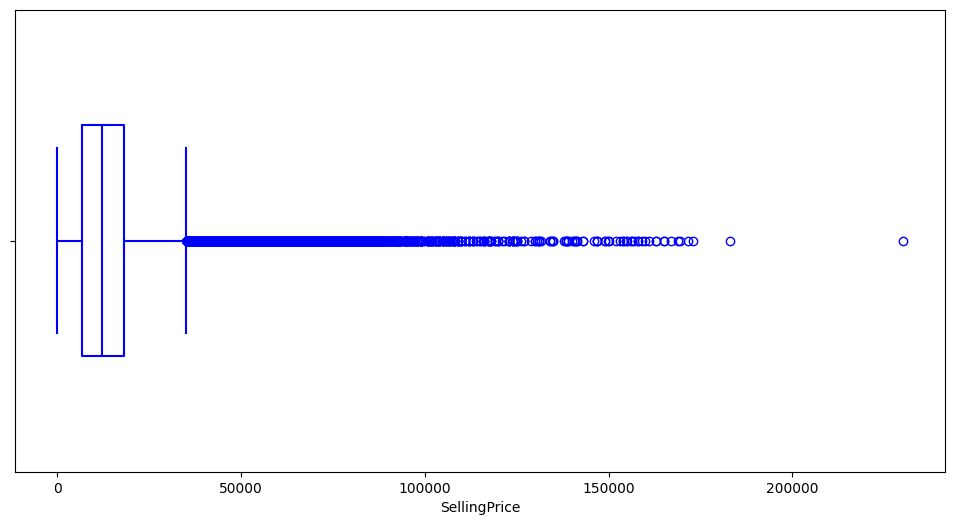

In [77]:
plt.figure(figsize=[12,6])
sns.boxplot(data=df,x='SellingPrice',widths=0.5,color="blue", saturation=0.6, fill=False)
plt.show()

In [78]:
Q1 = df['SellingPrice'].quantile(0.25)
Q3 = df['SellingPrice'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count = df[(df['SellingPrice'] < lower_bound) | (df['SellingPrice'] > upper_bound)].shape[0]

print(f" num_outliers: {outliers_count}")

 num_outliers: 16354


In [79]:
df.loc[df['SellingPrice'].idxmax()]

Id                                     344907
Year                                     2014
Make                                     Ford
Model                                  Escape
Trim                                 Titanium
Body                                      SUV
Transmission                        automatic
VIN                         1fmcu9j98eua23833
State                                      mo
ConditionValue                            4.3
Odometer                              27802.0
Color                                   green
Interior                                  tan
Seller            ford-lincoln dealer program
MMR                                   22800.0
SellingPrice                         230000.0
SaleDate                  2015-02-24 18:00:00
Name: 344905, dtype: object

In [80]:
df.loc[df['SellingPrice'].idxmin()]

Id                               7568
Year                             2002
Make                             Ford
Model                F-350 Super Duty
Trim                              XLT
Body                         Crew Cab
Transmission                      NaN
VIN                 1ftsw31f52ed16477
State                              ca
ConditionValue                    2.0
Odometer                          NaN
Color                           white
Interior                         gray
Seller                    laa leasing
MMR                            7850.0
SellingPrice                      1.0
SaleDate          2015-02-04 20:00:00
Name: 7566, dtype: object



* **Price Range & Data Quality:** Selling prices in the dataset vary from **1** to **230,000**. However, the minimum price of **1** is clearly a **data entry error** or a placeholder, as it does not reflect a realistic market value.
* **Price Distribution:** The average selling price is approximately **13,611**, while the median is **12,100**. Since the median is lower than the average, it indicates that the majority of cars are sold at lower prices.
* **Impact of Outliers:** The difference between the mean and median is caused by extreme high-value sales that pull the average up. For instance, the most expensive vehicle is a **Ford** sold at **230,000**, which stands out as a major outlier.
* **Key Insight:** While most sales are concentrated around the 12,000 range, these high-end outliers significantly affect the statistics. We will analyze them further in the **Bivariate analysis** to see how factors like model and mileage justify such high prices.

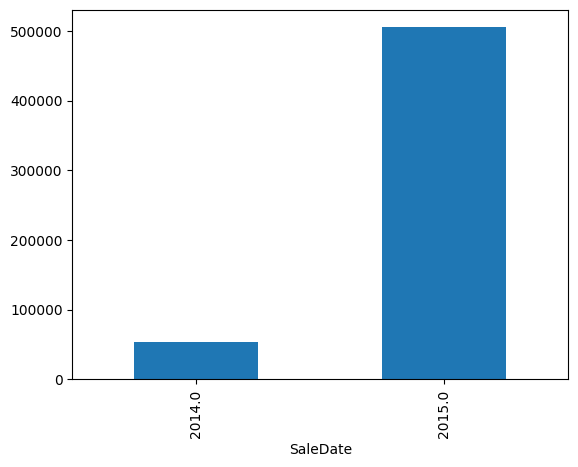

In [81]:
df['SaleDate'] = pd.to_datetime(df['SaleDate'])

df['SaleDate'].dt.year.value_counts().sort_index().plot(kind='bar')
plt.show()

* **Market Peak:** There was a major jump in sales in **2015** compared to **2014**.
* **Activity Levels:** This shows that market activity reached its highest point during 2015, while other years had much lower sales volumes.

## Bi variate

In [82]:
df.head()

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
0,2,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,2014-12-16 04:30:00
1,3,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,2014-12-16 04:30:00
2,4,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,4.5,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,2015-01-14 20:30:00
3,5,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,4.1,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,2015-01-28 20:30:00
4,6,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,4.3,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18 04:30:00


In [83]:
df.groupby('Year')['SellingPrice'].mean().sort_values(ascending=False)

Year
2015    25966.006801
2014    20090.200535
2013    17476.602700
2012    16653.749836
2011    15851.677185
1982    12750.000000
2010    12412.453313
2009    10462.313295
2008     9508.054092
2007     8021.969687
2006     6190.204808
1983     5250.000000
2005     4893.989857
2004     4321.474455
1985     3520.000000
2003     3447.268654
1988     3168.181818
2002     2611.709315
1986     2538.636364
1984     2160.000000
2001     2131.014224
2000     1827.834130
1989     1620.000000
1999     1533.696105
1987     1512.500000
1990     1435.714286
1998     1261.719404
1997     1157.454722
1992      991.666667
1996      985.781434
1991      943.656716
1995      913.292546
1994      870.599490
1993      833.902439
Name: SellingPrice, dtype: float64

In [84]:
df.groupby('Year')['SellingPrice'].describe()

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
1982,2.0,12750.000000,10960.155108,5000.0,8875.0,12750.0,16625.00,20500.0
1983,1.0,5250.000000,NaN,5250.0,5250.0,5250.0,5250.00,5250.0
1984,5.0,2160.000000,763.544367,1100.0,1800.0,2200.0,2600.00,3100.0
1985,10.0,3520.000000,1659.685378,550.0,2500.0,3425.0,4825.00,6200.0
1986,11.0,2538.636364,2624.437169,275.0,575.0,1400.0,4300.00,8600.0
1987,8.0,1512.500000,1973.892094,250.0,337.5,450.0,1875.00,5800.0
1988,11.0,3168.181818,4531.129701,200.0,475.0,900.0,4500.00,14700.0
1989,20.0,1620.000000,2337.826814,150.0,300.0,400.0,1350.00,7900.0
1990,49.0,1435.714286,2185.826741,200.0,325.0,500.0,1500.00,11500.0


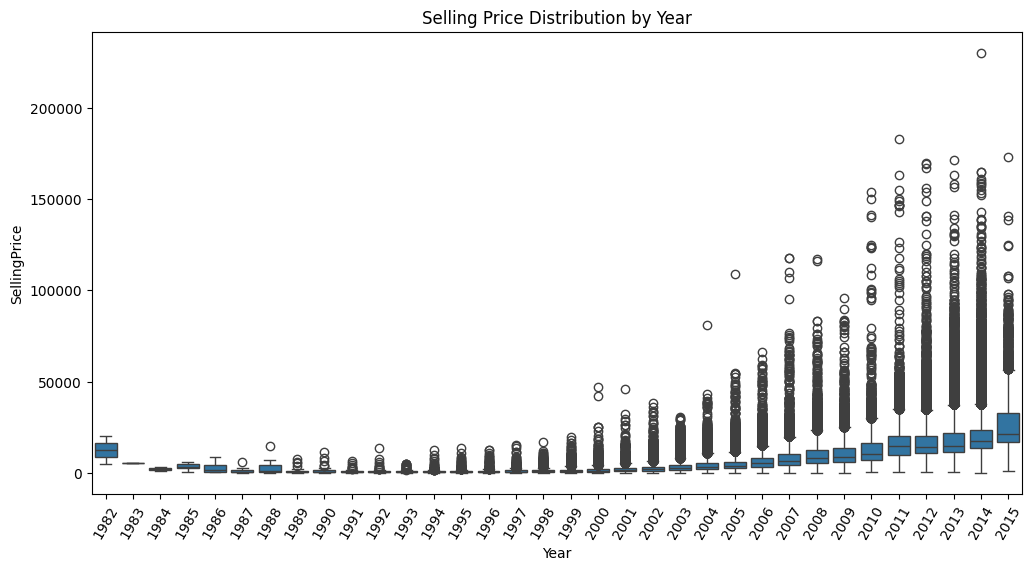

In [85]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Year', y='SellingPrice')
plt.title("Selling Price Distribution by Year")
plt.xticks(rotation=60)
plt.show()


* **Price Trends:** Generally, newer vehicles (**2011–2015**) have higher average selling prices. The year **2015** has the highest average at approximately **$25,966**, followed by 2014 and 2013.
* **High-Value Exceptions:** Even though newer cars are usually more expensive, some older years have very high prices. For example, a car from **2014** sold for **$230,000**, and even a car from **1982** reached **$20,500**.
* **Luxury & Classics:** These high prices come from **outliers** like luxury, high-performance, or classic cars that are worth much more than a typical vehicle.
* **Key Insight:** While the general rule is "newer is more expensive," these special outliers change the average. This shows why it is important to look at both the median and the price spread to understand the market truly.

In [86]:
df.groupby('Make')['SellingPrice'].max()

Make
Acura            47800.0
Aston Martin    103000.0
Audi            120000.0
BMW             165000.0
Bentley         163000.0
                  ...   
subaru            8800.0
suzuki            9700.0
toyota           26000.0
volkswagen       21800.0
vw               25000.0
Name: SellingPrice, Length: 96, dtype: float64

In [87]:
df.groupby('Make')['SellingPrice'].mean()

Make
Acura           14017.268260
Aston Martin    54812.000000
Audi            19915.432782
BMW             21441.895748
Bentley         74367.672414
                    ...     
subaru           3710.416667
suzuki           4810.000000
toyota           7339.105263
volkswagen       6145.833333
vw              13672.916667
Name: SellingPrice, Length: 96, dtype: float64

In [88]:
top_5_makes = df['Make'].value_counts().head(5).index
filter_make = df[df['Make'].isin(top_5_makes)]
best_models = filter_make.groupby(['Make', 'Model']).size().reset_index(name='count') \
                         .sort_values(['Make', 'count'], ascending=[True, False]) \
                         .groupby('Make').head(1)

print(best_models)

          Make          Model  count
24   Chevrolet         Impala   7923
70       Dodge  Grand Caravan   7941
108       Ford          F-150  14479
142     Nissan         Altima  19349
170     Toyota          Camry  12545


### Top Selling Models by Brand

* **Market Dominance:** Within the top 5 brands, specific models lead the sales volume, reinforcing the preference for practical and reliable vehicles.
* **Top Model Breakdown:**
    * **Nissan Altima:** The overall leader with **19,349** units sold, showing a massive demand for mid-size sedans.
    * **Ford F-150:** Follows with **14,479** units, proving that pickup trucks remain the backbone of the Ford lineup.
    * **Toyota Camry:** Maintains a strong position with **12,545** units, a staple in the mainstream sedan market.
    * **Dodge Grand Caravan:** Leads the family segment with **7,941** units sold, highlighting the steady demand for minivans.
    * **Chevrolet Impala:** A key performer for Chevrolet with **7,923** units.
* **Consumer Behavior:** The data shows that consumers consistently choose a brand's most "practical" or "established" models. This confirms that the volume of the used car market is driven by reliable, mid-range options rather than niche or luxury variants.

In [89]:
filter_make.groupby('Make')['SellingPrice'].agg(['mean','median','max','min'])

,mean,median,max,min
Make,,,,
Chevrolet,11977.397528,10500.0,88250.0,100.0
Dodge,11206.802592,10500.0,51700.0,100.0
Ford,14540.469648,13500.0,230000.0,1.0
Nissan,11739.015960,12000.0,86400.0,100.0
Toyota,12249.321813,12100.0,68900.0,150.0


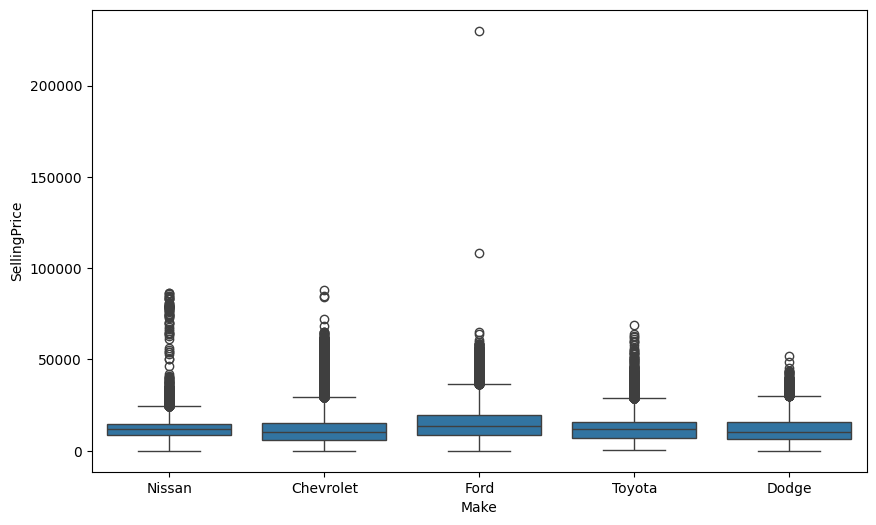

In [90]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=filter_make, x="Make", y="SellingPrice")
plt.show()


* **Market Popularity:** The most popular brands (**Ford, Chevrolet, Nissan, Toyota, and Dodge**) have average prices very close to the overall market average of **~$13,611**. This confirms that mid-priced vehicles are the most successful at attracting a wide range of buyers.
* **Brand Price Comparison:** * **Ford:** ~$14,540 (highest average among the top 5)
    * **Toyota:** ~$12,249
    * **Chevrolet:** ~$11,977
    * **Nissan:** ~$11,739
    * **Dodge:** ~$11,206
* **Price Distribution & Skewness:** While most sales stay near the median, brands like **Ford** show a very wide price spread. Ford's average is pulled upward by high-value outliers, such as a maximum price of **230,000**, likely representing high-performance or specialized models.
* **Volume vs. Price:** Ford and Chevrolet lead in total sales volume. This reinforces the insight that while luxury or specialized cars exist, the market is dominated by affordable, mid-range models.
* **Key Insight:** The "Right-Skew" in the data for these brands shows that a few expensive vehicle sales make the average look higher than what most people actually paid.

In [91]:
other_makes = df[~df['Make'].isin(filter_make)]

other_sample = other_makes['Make'].drop_duplicates().sample(5, random_state=42)
filter_random = df[df['Make'].isin(other_sample)]

In [92]:
filter_random.groupby('Make')['SellingPrice'].agg(['mean','median','max','min'])

,mean,median,max,min
Make,,,,
Aston Martin,54812.000000,51000.0,103000.0,38300.0
Bentley,74367.672414,62250.0,163000.0,22700.0
Land Rover,33097.855908,33000.0,135000.0,200.0
hyundai tk,2100.000000,2100.0,2100.0,2100.0
subaru,3710.416667,3450.0,8800.0,325.0


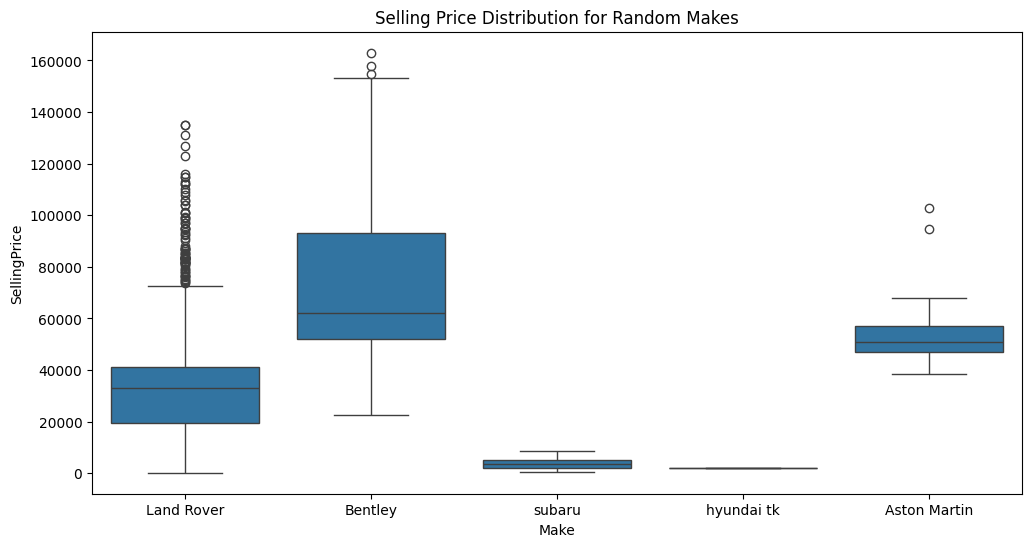

In [93]:
plt.figure(figsize=(12,6))
sns.boxplot(data=filter_random, x='Make', y='SellingPrice')
plt.title("Selling Price Distribution for Random Makes")
plt.show()


* **Luxury Outliers:** High-end brands like **Aston Martin and Bentley** show very high average and maximum prices. While most of their sales cluster around the median, a few extreme outliers push their maximum values significantly higher.
* **Mid-to-High Range (Land Rover):** **Land Rover** follows a similar luxury trend but contains an extreme low outlier of **200**. This is likely a **data entry error** or a sale of a non-functional parts car, as it does not reflect the brand's true market value.
* **Mass-Market & Budget Brands:** Brands like **Hyundai** and **Subaru** show much lower average prices and smaller price spreads. This consistency reflects their position as affordable, reliable vehicles for the general public.
* **Data Correction (Hyundai tk):** The entry listed as "Hyundai tk" likely refers to **Hyundai** (or potentially a specific model/fleet tag like the Kia Tasman 'TK' platform in recent data). In professional reports, it is best to group this under **Hyundai** to maintain consistency.
* **Key Insight:** Brands outside the Top 5 show the most diversity in the dataset. They represent two extremes: high-end luxury segments and affordable mass-market segments, highlighting the wide range of choices available in the market.

In [94]:
top_5_model= df['Model'].value_counts().head(5).index
filter_model = df[df['Model'].isin(top_5_model)]
best_trims = filter_model.groupby(['Model', 'Trim']).size().reset_index(name='count') \
                         .sort_values(['Model', 'count'], ascending=[True, False]) \
                         .groupby('Model').head(1)

print(best_trims)

     Model   Trim  count
1   Altima  2.5 S  11212
20   Camry     LE   6034
32  Escape     SE   3287
60   F-150    XLT   6637
63  Fusion     SE   8445


### Top Selling Trims by Model

* **The "Sweet Spot" Preference:** Across all top-selling models, buyers consistently favor mid-level trims. These versions typically offer the best balance of modern features and affordability, avoiding both the bare-bones "base" models and the overpriced "luxury" tiers.
* **Top Trim Breakdown:**
    * **Nissan Altima 2.5 S:** The standout leader with **11,212** units, making it the definitive choice for Altima buyers.
    * **Ford Fusion SE:** Shows very strong demand with **8,445** units, proving the SE trim is the primary driver for Fusion sales.
    * **Ford F-150 XLT:** With **6,637** units, the XLT remains the most popular configuration for truck buyers who need a mix of utility and comfort.
    * **Toyota Camry LE:** A classic favorite with **6,034** units, representing the core of the Camry's mainstream appeal.
    * **Escape SE:** With **3,287** units, it follows the trend for compact SUVs, where buyers prefer a moderately equipped package.
* **Key Insight:** This data confirms that "Value Trims" (like S, SE, LE, and XLT) are the true engine of the used car market. For a data scientist, this suggests that pricing models should be particularly sensitive to these specific trim designations, as they represent the highest transaction volume.

In [95]:
filter_model.groupby('Model')['SellingPrice'].agg(['mean','median','max','min'])

,mean,median,max,min
Model,,,,
Altima,11421.055765,12100.0,37200.0,100.0
Camry,11179.498446,12700.0,41200.0,150.0
Escape,13985.734930,15000.0,230000.0,225.0
F-150,18832.085020,19000.0,65000.0,200.0
Fusion,12353.226728,12700.0,49000.0,500.0


In [96]:
other_models = df[~df['Model'].isin(filter_model)]

random_models_sample = other_models['Model'].drop_duplicates().sample(5, random_state=42)
filter_random_models = df[df['Model'].isin(random_models_sample)]

In [97]:
filter_random_models.groupby('Model')['SellingPrice'].agg(['mean','median','max','min'])

,mean,median,max,min
Model,,,,
Explorer,18209.510056,22200.0,52750.0,200.0
Grand Vitara,5692.654639,5000.0,13700.0,300.0
Rogue Select,15273.684211,15800.0,22400.0,3300.0
Soul,11353.814734,11500.0,19000.0,1800.0
Transit Connect,11208.571429,9600.0,33300.0,500.0


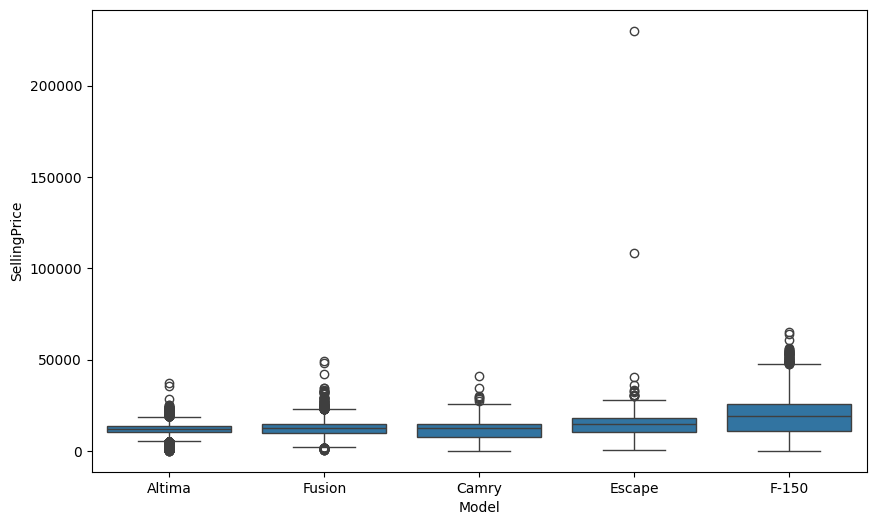

In [98]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=filter_model, x="Model", y="SellingPrice")
plt.show()

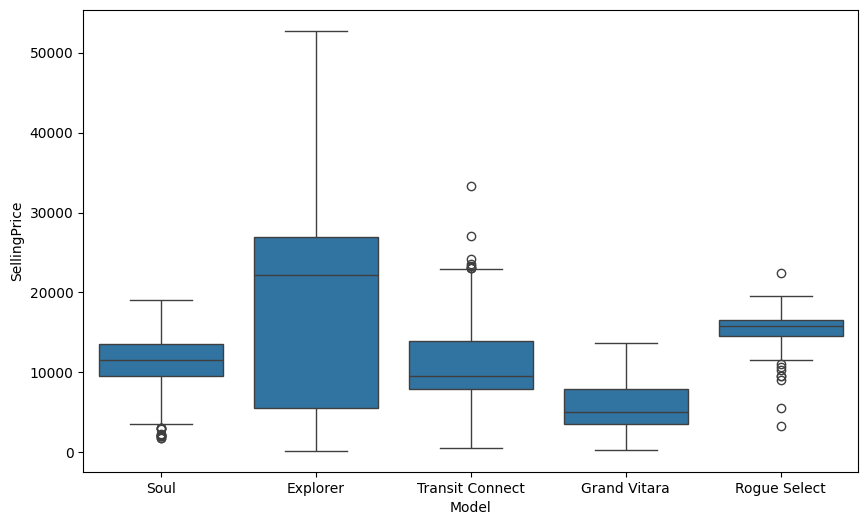

In [99]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=filter_random_models, x="Model", y="SellingPrice")
plt.show()

### Analysis of Top 5 Selling Models

* **Market Fit:** The top 5 models (**Altima, Camry, Fusion, F-150, and Escape**) are mostly mid-priced vehicles. Their average selling prices are close to the dataset mean of **~$13,611**, which explains their high demand.
* **The Ford Escape Outlier:** While the **Escape** is a common SUV usually sold around **$15,000**, it shows a maximum price of **$230,000**. This is a massive outlier; in a real-world context, a standard 2014/2015 Escape would never reach this price. This is likely a **data entry error** where a luxury car (like a Ferrari) was mislabeled as an Escape.
* **F-150 Performance:** The **F-150** shows a higher average price than the sedans, reflecting its popularity among buyers who need robust, high-utility vehicles which naturally hold more value.
* **Consistency:** The **Altima, Camry, and Fusion** show very stable prices with medians close to their means, indicating a highly predictable and steady market for these mid-size sedans.

---

### Analysis of Selected Models (Niche & Variety)

* **Ford Explorer:** This model has high average and median prices, but it contains an extreme low outlier of **200**. Similar to previous findings, this is likely an **erroneous entry** or a "scrap" sale, as it doesn't represent the true value of an Explorer.
* **Budget Friendly (Grand Vitara):** The **Grand Vitara** stands out as a budget-friendly option, with most sales concentrated around **$5,000**, making it a clear choice for the mass-market entry segment.
* **Mixed Segments:** Models like the **Rogue Select, Soul, and Transit Connect** target a variety of buyers. They show moderate price spreads, though some "rare" high prices push their maximum values up, suggesting the presence of high-trim or low-mileage units.
* **Key Insight:** The smaller models and less popular brands show more "noise" in the data (extreme highs and lows), highlighting why cleaning the data is important before making final price predictions.

In [100]:

top_5_trims = df['Trim'].value_counts().head(5).index
filter_top_trims = df[df['Trim'].isin(top_5_trims)]

In [101]:
filter_top_trims.groupby('Trim')['SellingPrice'].agg(['mean','median','max','min'])

,mean,median,max,min
Trim,,,,
Base,13870.038753,11700.0,183000.0,100.0
LT,13793.051315,12200.0,53000.0,200.0
LX,10289.226055,11000.0,31000.0,175.0
Limited,16587.790820,16000.0,52750.0,200.0
SE,11220.952756,11600.0,49000.0,100.0


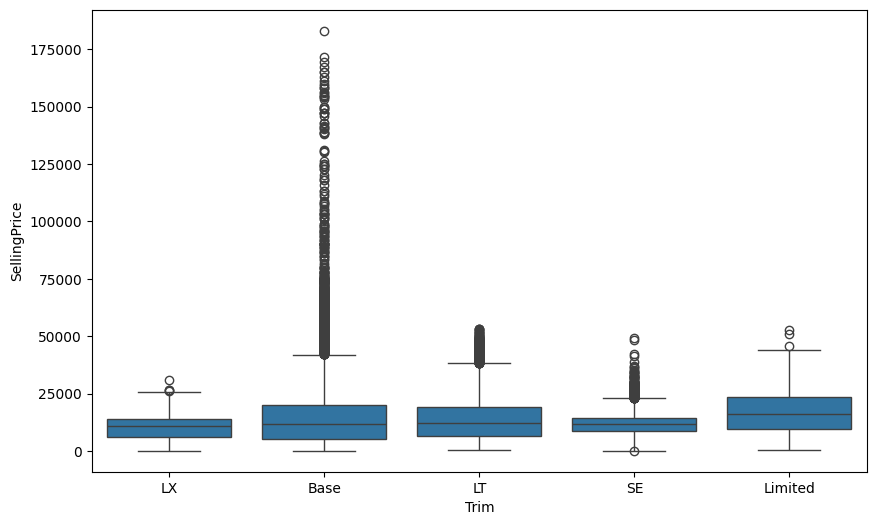

In [102]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=filter_top_trims, x="Trim", y="SellingPrice")
plt.show()

### Analysis of Top 5 Selling Trims

* **Mid-Range Dominance:** Most vehicles in the top 5 trims are sold at prices close to the median, confirming that buyers prefer "value-for-money" options.
* **Premium vs. Economy:**
    * **Limited:** This is the most expensive trim among the top 5, as it typically represents the premium or "high-spec" edition of a model.
    * **Base & LT:** These are the most popular mid-priced trims, offering a balance between essential features and cost.
    * **LX & SE:** These trims target the more affordable market segment, appealing to budget-conscious buyers.
* **Trim Outliers:** We noticed extreme high prices in the **Base, LT, SE, and Limited** categories. These are likely rare luxury variants or, more probably, **data entry errors** where expensive vehicles were incorrectly labeled with common trim names.
* **Key Insight:** The popularity of these five trims shows a diverse market where customers prioritize affordability and practical features, with only a small segment opting for the high-end "Limited" versions.

In [103]:
df.head()

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
0,2,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,2014-12-16 04:30:00
1,3,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,2014-12-16 04:30:00
2,4,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,4.5,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,2015-01-14 20:30:00
3,5,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,4.1,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,2015-01-28 20:30:00
4,6,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,4.3,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18 04:30:00


In [104]:
df.groupby('Body')['SellingPrice'].agg(['mean','median','max','min'])

,mean,median,max,min
Body,,,,
CTS-V Wagon,50500.000000,50500.0,50500.0,50500.0
Convertible,18236.536266,14500.0,163000.0,100.0
Coupe,16484.368150,14800.0,183000.0,100.0
Crew Cab,17773.048065,17500.0,65000.0,1.0
Hatchback,10045.733506,9900.0,67500.0,200.0
SUV,16115.916681,15100.0,230000.0,1.0
Sedan,11961.852514,11200.0,173000.0,1.0
Van,12355.712851,12500.0,84000.0,1.0
Wagon,10150.146248,8900.0,49500.0,100.0


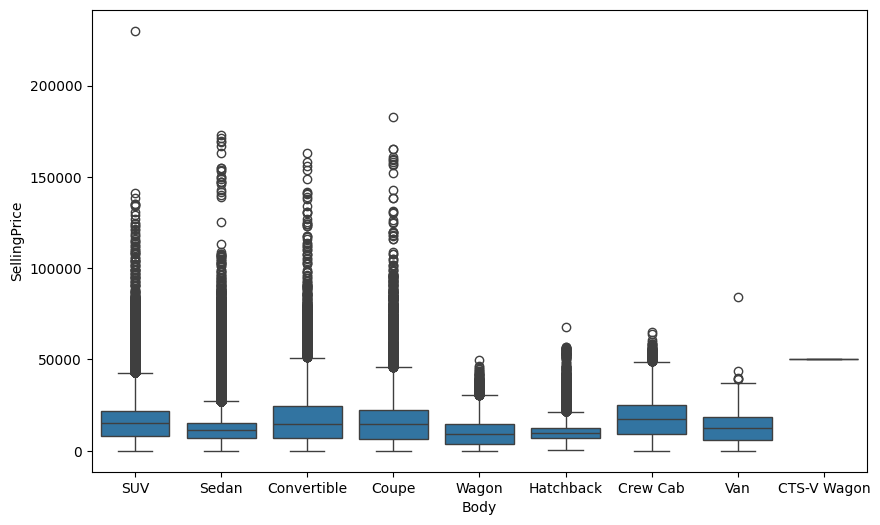

In [105]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Body", y="SellingPrice")
plt.show()

### Body Type Analysis

* **Market Leaders:** **Sedans and SUVs** dominate the market volume. Their average prices fall within the mid-range, making them the most practical and popular choices for the majority of buyers.
* **Luxury & Specialty Segments:** **Convertibles, Coupes, and the CTS-V Wagon** show significantly higher mean and maximum prices. These represent luxury or high-performance niche markets, which explains why they have fewer total sales compared to standard body types.
* **Budget-Friendly Options:** **Hatchbacks, Vans, and Wagons** tend to have lower average prices, targeting budget-conscious buyers or those looking for specific utility at a lower cost.
* **Widespread Outliers:** Nearly all body types show extreme price outliers. While some represent rare high-end editions, many are likely **data entry errors** (like a standard Sedan showing a supercar price), which can distort the average.
* **Key Insight:** The used car market is centered around practical, mid-priced body styles (Sedans/SUVs), while specialized body types command a premium price despite their lower sales volume.

In [106]:
df.groupby('State')['SellingPrice'].mean()

State
ab    11172.036638
al     9142.307692
az    11545.820366
ca    14505.902786
co    15877.798714
fl    13877.443559
ga    12918.774504
hi    12190.824576
il    14792.146946
in    10715.572254
la    10521.617070
ma     6726.742458
md     7409.753966
mi    14886.217974
mn    13708.186022
mo    14466.192344
ms    11244.130200
nc     8660.956420
ne    12572.956641
nj    13609.104161
nm     6291.812865
ns    10213.114754
nv    15097.772014
ny    11374.536761
oh    14406.619235
ok     6918.055556
on    17812.623475
or    11558.484848
pa    15976.303133
pr     9410.770642
qc    13292.971888
sc    10326.172195
tn    17009.744341
tx    13209.665258
ut    12065.625817
va     8574.737630
wa    13945.389563
wi    14003.529185
Name: SellingPrice, dtype: float64

In [107]:
df.groupby('State')['SellingPrice'].agg(['mean','median','max','min'])

,mean,median,max,min
State,,,,
ab,11172.036638,7500.0,39400.0,200.0
al,9142.307692,6850.0,28700.0,650.0
az,11545.820366,10300.0,78500.0,250.0
ca,14505.902786,12200.0,173000.0,1.0
co,15877.798714,14500.0,83000.0,250.0
fl,13877.443559,12500.0,183000.0,100.0
ga,12918.774504,11400.0,140500.0,1.0
hi,12190.824576,11750.0,45250.0,100.0
il,14792.146946,13900.0,134500.0,175.0


In [108]:
top_10_states = df['State'].value_counts().head(10).index
filter_top_states = df[df['State'].isin(top_10_states)]
filter_top_states.groupby('State')['SellingPrice'].agg(['mean','median','max','min']).sort_values(by='mean', ascending=False)


,mean,median,max,min
State,,,,
tn,17009.744341,16000.0,101200.0,350.0
pa,15976.303133,14200.0,154750.0,100.0
il,14792.146946,13900.0,134500.0,175.0
ca,14505.902786,12200.0,173000.0,1.0
oh,14406.619235,12500.0,113000.0,200.0
fl,13877.443559,12500.0,183000.0,100.0
nj,13609.104161,12200.0,103000.0,100.0
tx,13209.665258,11700.0,138500.0,1.0
ga,12918.774504,11400.0,140500.0,1.0


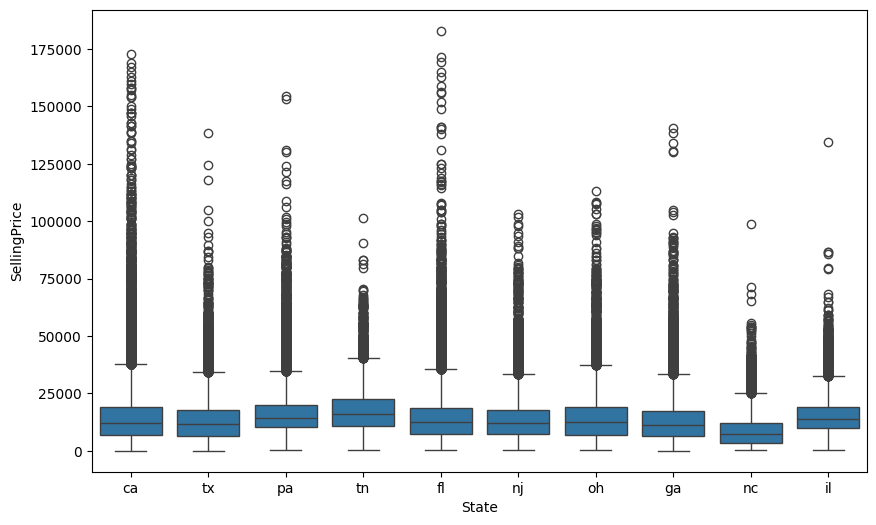

In [109]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=filter_top_states, x="State", y="SellingPrice")
plt.show()

### Geographical Analysis (Top 10 States)

* **High-Value Markets:** **Tennessee (TN) and Pennsylvania (PA)** stand out with the highest average selling prices among the top 10 states. This suggests a market trend in these regions toward more expensive or newer vehicle purchases.
* **Affordable Markets:** States like **North Carolina (NC) and Georgia (GA)** show lower mean and median prices, indicating a stronger market for budget-friendly and affordable vehicles.
* **Price Extremes:** Almost all states show very high maximum prices, reflecting the presence of luxury or rare vehicles across the country. 
* **Data Quality Note:** The extremely low minimum prices found in some states are likely **data entry errors** or sales of non-functional "scrap" vehicles rather than typical market transactions.
* **Key Insight:** Selling prices vary significantly by state, which reflects regional economic differences, local demand, and the occasional influence of high-end luxury outliers on the state's average.

In [110]:
df.head()

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
0,2,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,2014-12-16 04:30:00
1,3,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,2014-12-16 04:30:00
2,4,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,4.5,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,2015-01-14 20:30:00
3,5,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,4.1,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,2015-01-28 20:30:00
4,6,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,4.3,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18 04:30:00


In [111]:
df[['SellingPrice', 'ConditionValue']].corr()

,SellingPrice,ConditionValue
SellingPrice,1.000000,0.538785
ConditionValue,0.538785,1.000000


C:\Users\asus\AppData\Local\Temp\ipykernel_15200\2752084105.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x="ConditionValue", y="SellingPrice", palette=sns.color_palette("Set2"))


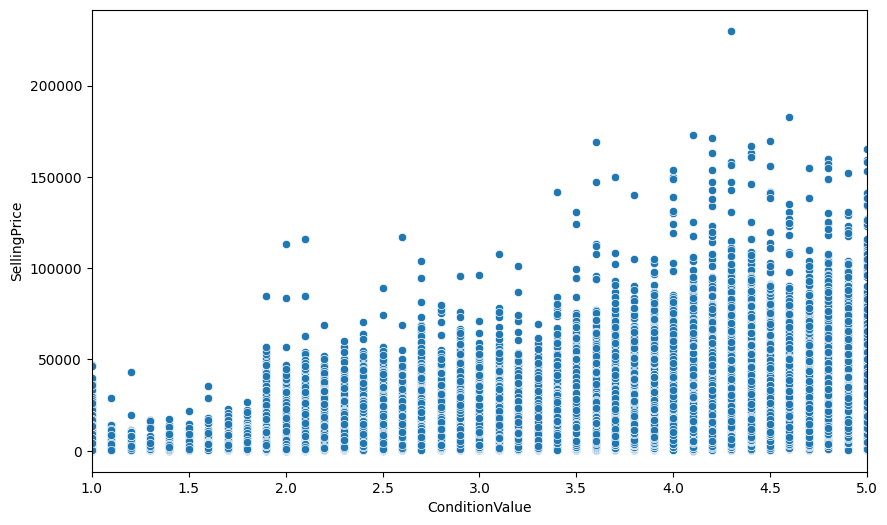

In [112]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="ConditionValue", y="SellingPrice", palette=sns.color_palette("Set2"))
plt.xlim(1,5)
plt.show()

### Condition vs. Selling Price Correlation

* **Positive Correlation:** There is a **moderate positive correlation ($r = 0.54$)** between a car’s condition score and its final selling price. 
* **Value Impact:** This score confirms that as the condition of a vehicle improves, the selling price generally increases. However, since the correlation isn't "strong" (it's not near 0.9), it shows that condition is just one piece of the puzzle.
* **Multivariate Influence:** While a well-maintained car fetches more money, other factors—such as **brand, model, manufacturing year, and mileage**—collectively play a significant role in determining the final price.
* **Key Insight:** Consistent maintenance and keeping a car in good condition are statistically likely to boost its resale value, though they cannot fully overcome the depreciation of a less popular brand or very high mileage.

In [113]:
df[['SellingPrice', 'Odometer']].corr()

,SellingPrice,Odometer
SellingPrice,1.000000,-0.582415
Odometer,-0.582415,1.000000


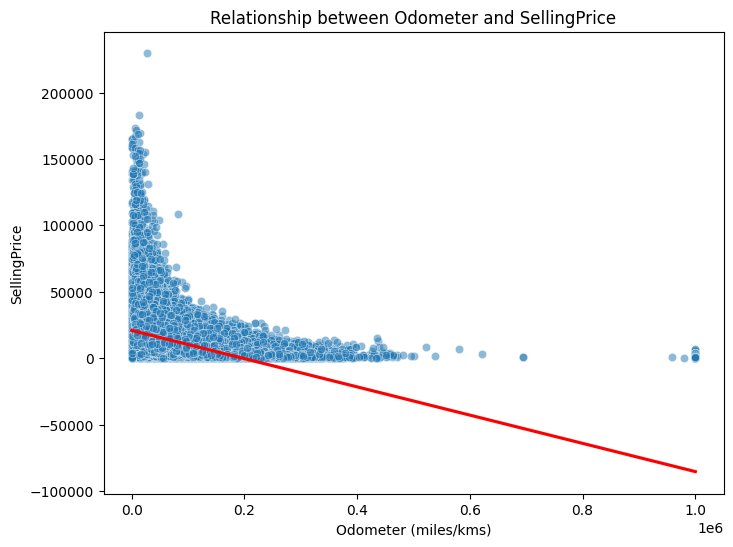

In [114]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Odometer', y='SellingPrice', alpha=0.5)
sns.regplot(data=df, x='Odometer', y='SellingPrice', scatter=False, color='red')
plt.title('Relationship between Odometer and SellingPrice')
plt.xlabel('Odometer (miles/kms)')
plt.ylabel('SellingPrice')
plt.show()

### Odometer vs. Selling Price Correlation

* **Negative Correlation:** There is a **moderate negative correlation ($r = -0.58$)** between a car's odometer reading (mileage) and its selling price. 
* **Depreciation Trend:** This relationship indicates that as mileage increases, the selling price typically decreases. This reflects the natural depreciation of a vehicle as it undergoes more usage and wear over time.
* **Mileage Distribution:** The majority of cars in this dataset fall within the **28,000 km to 99,000 km** range. 
* **Outliers & Data Integrity:** Some extreme outliers exist in the mileage data. While these could represent very old, high-usage vehicles, they may also be **data entry errors** that could skew the analysis if not handled carefully.
* **Key Insight:** Mileage remains a critical factor in determining resale value. While other factors like brand or condition matter, a lower odometer reading is a strong and consistent driver of higher market prices.

In [115]:
df.groupby('Color')['SellingPrice'].agg(['mean','median','max','min'])

,mean,median,max,min
Color,,,,
beige,9431.169269,7600.0,112000.0,200.0
black,15509.004749,13500.0,169500.0,1.0
blue,11440.609234,10500.0,147000.0,150.0
brown,15352.808099,14000.0,108000.0,200.0
burgundy,11902.997548,11400.0,113000.0,150.0
charcoal,16247.496868,13800.0,134000.0,800.0
gold,8324.714953,6100.0,68000.0,150.0
gray,13951.472880,12500.0,159000.0,100.0
green,8301.808733,5600.0,230000.0,100.0


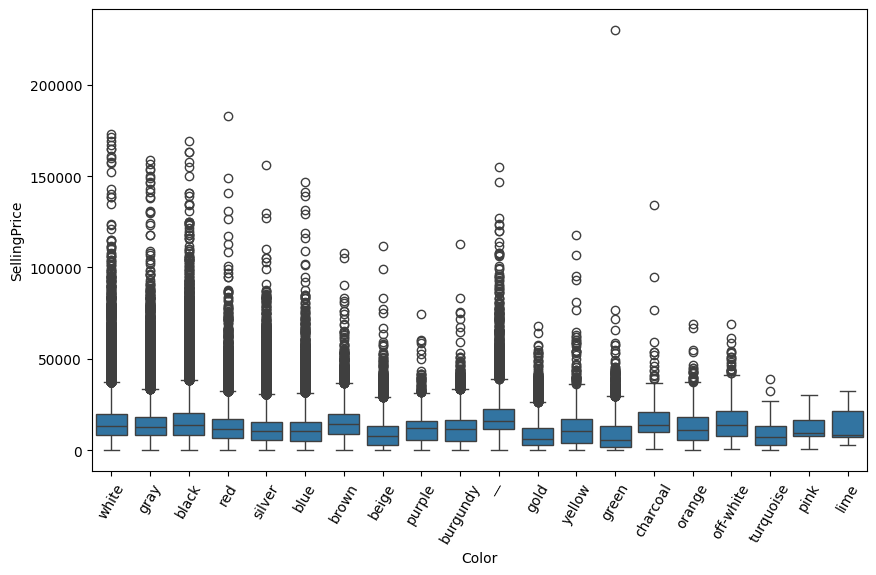

In [116]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Color", y="SellingPrice")
plt.xticks(rotation=60)
plt.show()

Color Analysis

* **Premium & Popular Colors:** **Black, Charcoal, and White** dominate the market. These colors command higher-than-average selling prices, reflecting a strong buyer preference for classic, high-resale colors.
* **Mid-Range Demand:** Colors such as **Brown, Gray, Red, and Off-white** fall into the mid-range price category, showing steady demand without a premium price tag.
* **Budget-Friendly Options:** Colors like **Beige, Gold, Green, Turquoise, and Lime** are associated with lower average prices, typically representing affordable, mass-market vehicles.
* **Luxury Outliers:** Extreme maximum prices are seen in **Black, Red, and Green**. These are high-end outliers, likely luxury or sports cars where the color is part of a high-performance or rare package.
* **Key Insight:** While color is a major factor for buyer preference, it has a limited impact on the "typical" price, as most popular colors stay clustered around the overall market average.

In [117]:
df.groupby('Interior')['SellingPrice'].agg(['mean','median','max','min'])

,mean,median,max,min
Interior,,,,
beige,13348.510794,12000.0,171500.0,100.0
black,15679.543406,13800.0,183000.0,1.0
blue,8237.038664,3900.0,80250.0,150.0
brown,20241.964815,18750.0,165000.0,200.0
burgundy,19664.136126,16500.0,83750.0,175.0
gold,11420.061728,10050.0,47700.0,250.0
gray,11026.903608,10000.0,161000.0,1.0
green,10049.183673,8600.0,32100.0,100.0
off-white,29045.989583,28750.0,149000.0,900.0


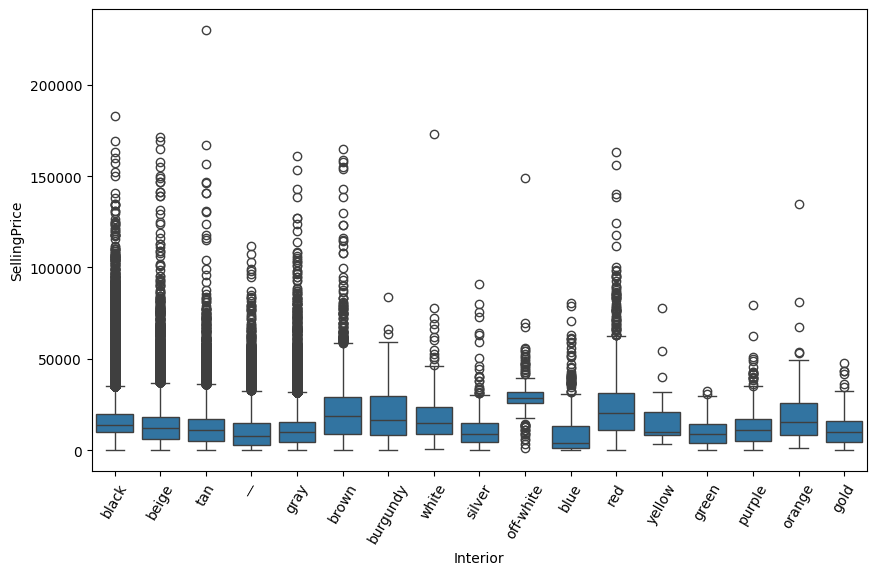

In [118]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Interior", y="SellingPrice")
plt.xticks(rotation=60)
plt.show()

Interior Color Analysis

* **Luxury & Premium Trims:** The interior color has a noticeable impact on price, particularly in the high-end segment. **Red, Off-white, Brown, White, and Orange** interiors are associated with higher-than-average selling prices, often signaling premium trims or luxury models.
* **Mainstream Interiors:** Common colors like **Black, Beige, Burgundy, and Tan** have mid-range prices, representing the bulk of mainstream, everyday vehicles.
* **Economical Choices:** **Gray, Blue, Gold, Green, and Silver** interiors correspond to the lowest average prices, reflecting more budget-conscious, mass-market cars.
* **Outlier Alert:** Some interior colors show extreme price peaks (e.g., **Tan at 230,000** and **Black at 183,000**). These are clear outliers representing luxury supercars or rare collectibles.
* **Key Insight:** Interior color serves as a strong indicator of a car's "class." Premium colors are almost exclusively found in high-value vehicles, while standard colors dominate the mid-market price range.

In [119]:
top_seller = df['Seller'].value_counts().head(5).index
df_top_seller = df[df['Seller'].isin(top_seller)]

In [120]:
df_top_seller.groupby('Seller')['SellingPrice'].agg(['mean','median','max','min'])

,mean,median,max,min
Seller,,,,
avis corporation,16222.673844,13800.0,54000.0,1200.0
ford motor credit company llc,17793.556257,16850.0,58400.0,400.0
nissan-infiniti lt,13817.323922,13500.0,81000.0,3700.0
santander consumer,7935.041871,7400.0,51000.0,175.0
the hertz corporation,13709.118968,11700.0,124000.0,175.0


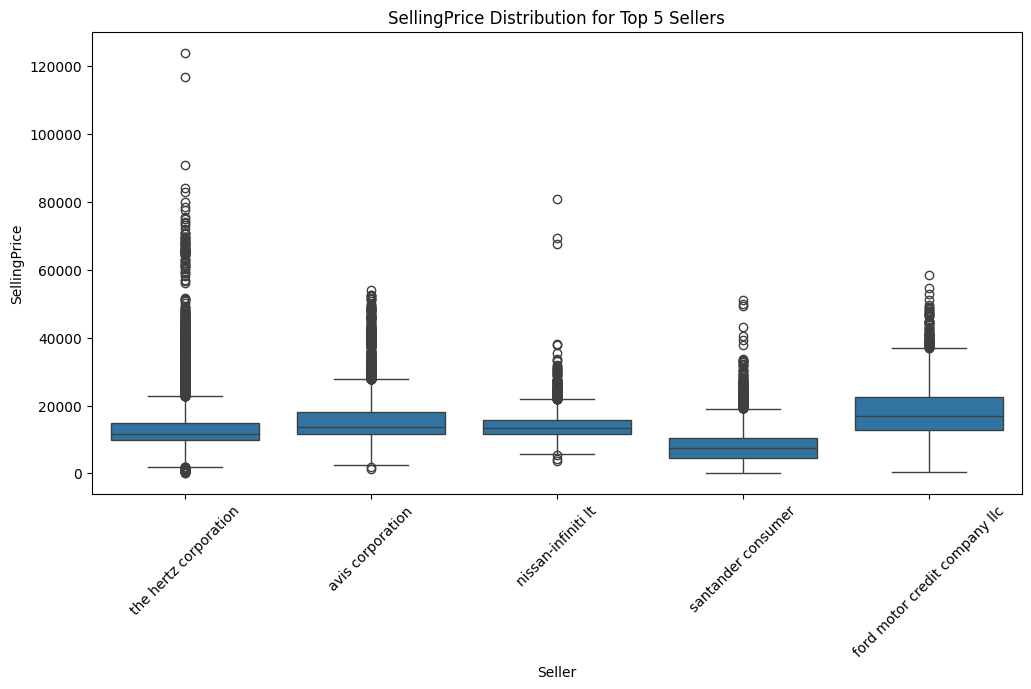

In [121]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_top_seller, x='Seller', y='SellingPrice')
plt.xticks(rotation=45)
plt.title('SellingPrice Distribution for Top 5 Sellers')
plt.show()

### Seller Strategy & Price Analysis

* **Premium & Fleet Positioning:** **Ford Motor Credit Company LLC** and **Avis Corporation** maintain higher-than-average mean prices (approx. **17,800** and **16,200** respectively). This suggests their inventory consists of newer models, off-lease vehicles, or premium fleet units.
* **Mid-Market Stability:** **Nissan-Infiniti LT** and **The Hertz Corporation** show mean prices around the **13,700–13,800** range. This aligns closely with the overall market average, indicating a focus on mainstream, high-demand vehicles.
* **Budget-Focused Sellers:** **Santander Consumer** stands out with a much lower mean price of approximately **7,900**. This highlights a market positioning focused on the affordable, entry-level, or high-mileage vehicle segment.
* **Luxury Outliers in Rental Fleets:** While **Hertz** has a mid-range average, it shows a maximum price of **124,000**. This indicates that while most of their stock is standard, they also handle high-end luxury or specialty "dream cars" that act as price outliers.
* **Key Insight:** A seller's identity is a strong indicator of the vehicle's price range. The data shows a clear divide between corporate/finance sellers dealing in newer inventory and consumer-finance entities focusing on the budget market.

In [122]:
df[['MMR', 'SellingPrice']].corr()

,MMR,SellingPrice
MMR,1.000000,0.983635
SellingPrice,0.983635,1.000000


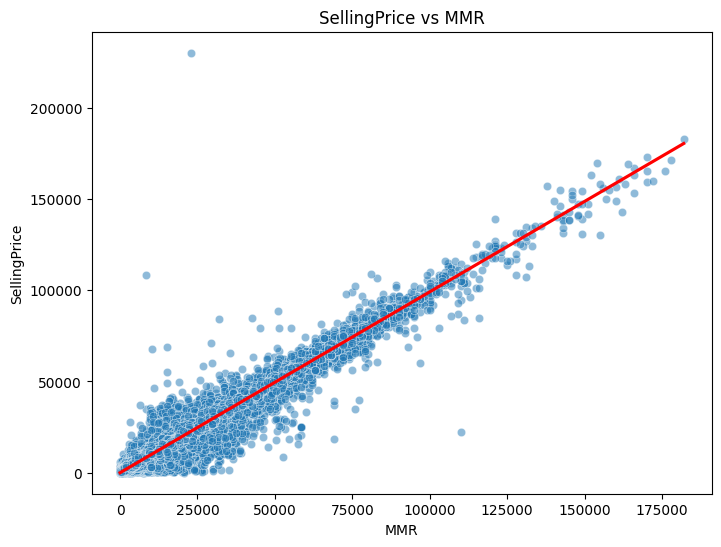

In [123]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='MMR', y='SellingPrice', alpha=0.5)
sns.regplot(data=df, x='MMR', y='SellingPrice', scatter=False, color='red')
plt.title('SellingPrice vs MMR')
plt.show()

### MMR vs. Selling Price Correlation

* **Exceptional Correlation:** There is an **extremely strong positive correlation ($r = 0.98$)** between the MMR (Market Median Retail) and the actual Selling Price.
* **Predictive Accuracy:** This near-perfect relationship indicates that the MMR is a **highly reliable predictor**. In this dataset, the expected market value and the final transaction price move almost perfectly in sync.
* **Market Consistency:** The data shows very consistent market behavior: cars with high MMR values almost always result in high selling prices, while lower-valued MMR entries correspond to lower sales.
* **Key Insight:** Because these two variables are so closely linked, any significant deviation (where Selling Price is much higher or lower than MMR) would be a major red flag for either a unique "deal" or a **data entry error**.

In [124]:
df.groupby('Transmission')['SellingPrice'].agg(['mean','median','max','min'])

,mean,median,max,min
Transmission,,,,
automatic,13540.406866,12100.0,230000.0,1.0
manual,11211.448358,8600.0,105000.0,150.0


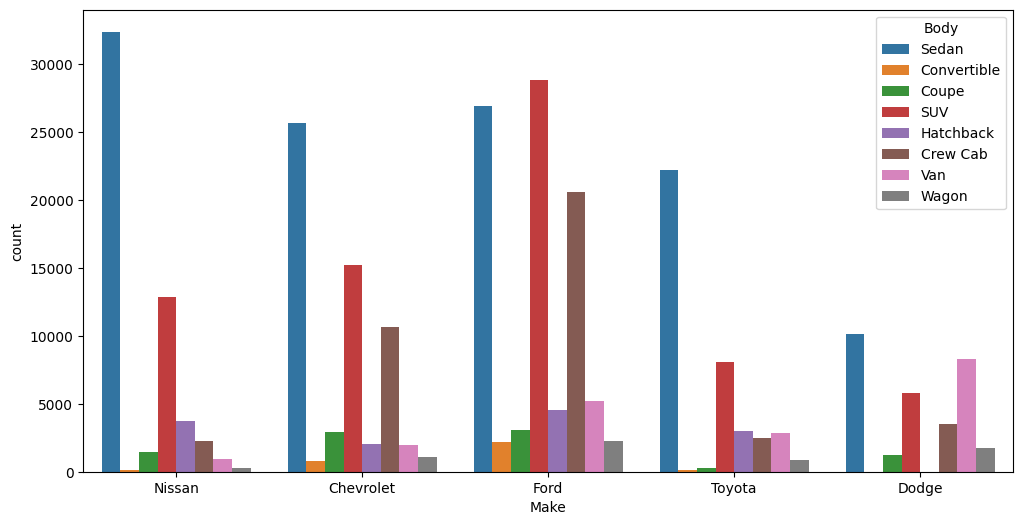

In [125]:
plt.figure(figsize=[12,6])
sns.countplot(data=filter_make, x="Make", hue="Body")
plt.show()

In [126]:
corr = df[['ConditionValue', 'Odometer']].corr()
print(corr)

                ConditionValue  Odometer
ConditionValue        1.000000 -0.538874
Odometer             -0.538874  1.000000


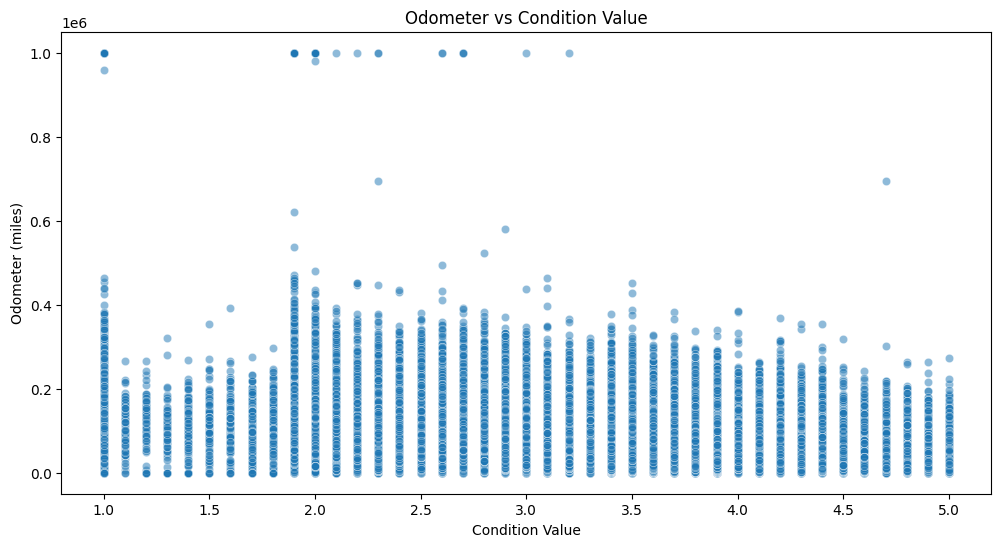

In [127]:
plt.figure(figsize=(12,6))

sns.scatterplot(data=df, x='ConditionValue', y='Odometer',alpha=0.5)
plt.title('Odometer vs Condition Value')
plt.xlabel('Condition Value')
plt.ylabel('Odometer (miles)')
plt.show()

### Odometer vs. Condition Value Correlation

* **Negative Correlation:** There is a **moderate negative correlation ($-0.58$)** between a car’s odometer reading (mileage) and its condition value. 
* **The Wear and Tear Trend:** This relationship confirms that as mileage increases, the condition rating tends to decrease. This is a logical reflection of the physical wear and tear that accumulates as a vehicle is driven more.
* **Condition Extremes:**
    * **Low Mileage:** Generally corresponds to higher condition scores, as these vehicles have likely faced less mechanical stress and interior/exterior aging.
    * **High Mileage:** Typically results in lower condition ratings, representing the expected degradation of a vehicle over time.
